# Feature analysis — `mid_rate_surge`

This notebook follows the project's feature-analysis **method** (copy of the `price_dislocation`
template) on a new feature: **`mid_rate_surge`** — a fast/slow ratio of a venue's **mid-update rate**.
The text says what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the model these features feed.

**The feature, in one line.** A venue's **mid-update rate** is how often *that venue's* mid *changes*,
per second. Smooth that rate two ways — a **fast** EMA and a **slow** EMA — and take the ratio:

`mid_rate_surge(ex; fast, slow) = EMA_fast(ex mid-update-rate) / EMA_slow(ex mid-update-rate)`

A ratio above 1 means that venue is quoting/repricing *faster than usual* right now — a quoting-activity
**surge**; below 1, a lull. The hypothesis is that a surge **predicts intensity**: when a venue starts
repricing quickly, more byb mid-moves are about to follow.

**This is a per-exchange feature (like the template's dislocation gap).** Exactly as
`price_dislocation` computes a gap for *each* non-byb venue, we compute a surge for **each** venue —
byb, okx **and** bin — each from that venue's OWN mid-moves, and ask whether it predicts **byb's** next
move. The byb leg is the *target's own* tempo; the okx/bin legs are **cross-venue** quoting-tempo
lead/lag.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the optimized build really computes what we think it does (bit-exact vs a
  dead-simple independent streaming build, on a real block, **for every per-exchange leg**).
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is busy right now."

> **Control-circularity caveat (read this first — and note it is now PER LEG).** byb's mid-update
> *rate* is exactly the quantity the model's **rate yardstick `λ_ev`** measures, so **byb's own**
> `mid_rate_surge` leg is essentially **`rate_momentum`, one of the §5 controls**, built as its own
> family — it is *not* expected to add much *over the rate control*. **But the okx/bin legs are NOT
> circular** with byb's controls: they are *another venue's* quoting tempo, and they genuinely test
> cross-venue lead/lag. So the honest question splits per leg: the byb leg's value (if any) is span
> tuning over the control; the okx/bin legs' value (if any) is **new cross-venue information**. §6/§9
> quantify each, straight.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the
model does. We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size, together), in units of byb's recent **volatility** — the **volatility
yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual* mid-moves)? Target: `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms, measured against the recent pace — the
**rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but
**updated between trades**. `λ_ev` is byb's **mid-moves per second** = the exp-weighted byb move-count
`W` ÷ the exp-weighted seconds-per-trade. **`mid_rate_surge` is built from exactly the same `W / dt`
rate machinery — per venue, at two spans, as a ratio.** That is the whole point of the caveat above: the
raw atom of the *byb* leg *is* the rate the rate yardstick measures; the okx/bin legs are the same atom
for *other* venues.

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each one
is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing. This
"how many × how big" split is the classic **subordination** model of asset prices (Clark, 1973; Ané &
Geman, 2000): returns over fixed clock-time look messy but become well-behaved once you condition on the
*number* of events. `mid_rate_surge` is squarely a **how-many** feature — it speaks to the rate head.

Two diagnostics recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude* predict how many moves come (rate head)? The model is fed the **signed** feature for *both*
heads; the rate head learns the magnitude itself. For `mid_rate_surge` we expect the rate head to be
where it lives, if anywhere.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the
  feature the same way for **every** venue and keep them all. (Here that is literal: byb, okx and bin
  each get their own surge leg; the okx/bin legs are exactly the "does another venue lead byb?" test.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another venue
  leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** Check per-exchange vs single vs pooled across time-scales (§9).
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — *especially for
  the byb leg*, which is a near-twin of the rate control and could be re-reporting it.
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version — for
  **every** per-exchange leg.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't normalize reflexively.** `mid_rate_surge` is a **ratio of two rates** — already
  dimensionless and comparable across calm/busy markets — so it needs **no** yardstick division.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a surge in a venue's repricing tempo precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any time-scale (or, for the byb leg, it's
  fully explained by the rate control; for okx/bin, no cross-venue marginal).
- **Do make every average a trade-tick EMA.** *Every* smoother — every venue's rate legs, `σ_ev`,
  `λ_ev` — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet
  **updated on every relevant event between trades** (a venue's mid-move injects; the clock decays on a
  trade), never a wall-clock or boxcar window. O(1) state, bit-identical online vs offline.
- **Do read a sparse flow as `E / W` on the shared clock.** Each venue's mid-moves are present on only
  *some* events; the rate's numerator is that venue's exp-weighted move count `W`, decayed every trade
  on the **one** shared clock, injected only on **that venue's** move, read live. The `E/W` form makes a
  merged-clock EMA approximate that venue's **own**-clock EMA at a rescaled span — so we get genuine
  per-venue rates from one clock (tight at large spans, fraying at small spans where cross-venue lead/lag
  lives — exactly the regime §9 probes).
- **Do treat all records sharing a timestamp as ONE event.** The decay clock advances **once** per
  trade-timestamp; a venue's N simultaneous prints are one event, at most one mid-move.
- **Do test against both heads — but feed both the *signed* feature.** The magnitude→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect to be weak.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and sweep the WHOLE fast×slow grid, per venue.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a venue's mid-update **rate** (mid-moves per second), smoothed fast vs slow, as a **ratio** — one per venue (byb, okx, bin) |
| **feeds** | the **rate head** (intensity: how many byb moves next) is the natural home; price-head is a diagnostic |
| **predicts** | byb's 100 ms move-count (and, weakly if at all, direction) |

**The idea.** Count how often a venue's mid *changes*. Express it as a rate — moves per second — using
the exact `W / dt` form the rate yardstick uses. Smooth that rate two ways (a *fast* EMA, a *slow* EMA)
and divide: `surge = rate_fast / rate_slow`. Above 1 = that venue is repricing faster than its recent
baseline; below 1 = slower. **Do this for byb, okx and bin** — the byb leg is the target's own tempo,
the okx/bin legs are other venues' tempo.

**Why it should work.** Quoting activity clusters. When market-makers start repricing a venue quickly —
news, an inventory shock, a cross-venue move propagating in — the elevated tempo persists for tens to
hundreds of milliseconds, so a fresh **surge** forecasts a **burst** of upcoming byb mid-moves. For the
**cross-venue** legs there is an extra mechanism: if okx (or bin) starts repricing first, that tempo can
**lead** byb's by a beat — the classic no-fixed-leader lead/lag the template warns about. That is an
*intensity* statement: it speaks to *how many* moves, not *which way* — so the **rate head**.

**Why the byb leg might NOT add (the caveat, quantified later).** byb's mid-update rate **is** `λ_ev`. A
fast/slow ratio of it **is** rate momentum — one of the four §5 controls. So byb's own leg risks being a
re-parameterised control with little *marginal* value over `rate_momentum`. **The okx/bin legs carry no
such circularity** — they are other venues' rates, not byb's control — so their marginal, if positive, is
genuinely new cross-venue information. §6/§9 measure each leg straight.

**What would disprove it.** No link to the forward byb move-count at any (fast, slow) for any venue; the
byb leg's link vanishing once we control for `rate_momentum`/`rate_level` (it *was* the rate control); or
the okx/bin legs adding ≈0 over byb's controls (cross-venue tempo carries nothing byb's own doesn't).

> **No fixed leader.** Built the same way for every venue, all kept. The okx/bin legs are precisely the
> "another venue might lead" test; the trade clock pools all three venues' trades (the shared "tick").

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every relevant event in between**, so a read between
trades is never stale. For each venue's `mid_rate_surge` the moving parts are:

- **The move-count numerator `W_ex`** — a **sparse flow** (venue `ex` moves on only *some* events). It
  is an EMA that **decays every trade** (on the shared clock) and **injects `1` on every `ex` mid-move**,
  read **live**. This is the same `E/W`-style flow the yardsticks use, read at the anchor so the count
  reflects every move since the last trade. Per the merged-clock↔own-clock equivalence, dividing through
  by the common decay makes this a *per-venue* rate even though all venues share one clock.
- **The seconds-per-trade denominator `dt`** — a **per-trade** EMA of the gap between consecutive
  trade-timestamps, held flat between trades. This is a property of the **shared clock**, so it is the
  same for every venue; the per-venue content lives entirely in `W_ex`.

So `rate_ex(span) = W_ex(span) / dt(span)` = venue `ex`'s mid-moves per second at that span, and the
feature is `rate_ex(fast) / rate_ex(slow)`. Both spans share the one trade clock; the **ratio** cancels
the warm-up and the common decay factor — no yardstick division needed.

The trap the template warns about (push a `0` on a non-move and "per move" silently becomes "per trade")
applies here too: `W_ex` must inject **only** on a real `ex` mid-move, and **once** per timestamp
(simultaneous prints are one event). The §4 oracle re-derives all of this from raw events, per venue, and
confirms it bit-exact.

## 2. The exact definition

A definition has to get three things right.

**Causal** — only data up to the moment it's computed; no peeking. (A stray forward-fill is the usual
accidental break.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than
clock-seconds. A venue's mid-moves between trades update what the EMA *reads* but do **not** advance the
clock; only a trade decays the EMAs once.

**Comparable across calm and wild markets** — and here it already is: `mid_rate_surge` is a **ratio of
two rates**, so the absolute pace cancels. **No `σ_ev` / `λ_ev` division** is applied to the feature. The
yardsticks still appear — to build the §5 controls and the rate-head *target* — but not inside the
feature.

Put it together, **for each venue `ex`**:

**2a — The shape** (the whole idea, in one line):

`mid_rate_surge(ex) = rate_ex,fast / rate_ex,slow`,  where  `rate_ex(N) = W_ex(N) / dt(N)` = ex mid-moves/sec.

A fresh acceleration on venue `ex` shows up as its fast rate pulling above its slow one (ratio > 1).

**2b — The EMAs we use, and how they update:**

- **`W_ex(N)`** (per-venue move-count numerator) — a **sparse flow**: decay once per trade-timestamp on
  the shared clock (`α=2/(N+1)`), inject `1` on each real `ex` mid-move, read **live** at the anchor.
- **`dt(N)`** (seconds-per-trade denominator) — a **per-trade** EMA of `Δ(trade timestamp)/1e9`, held
  flat between trades; a property of the shared clock (same for all venues).
- **`σ_ev`, `λ_ev`** (yardsticks, span `YARDSTICK_N`) — used only for the controls and the rate-head
  target: `σ_ev = √(E/W)` over **byb** moves; `λ_ev = W_byb / dt` at `YARDSTICK_N` (note: `λ_ev` is
  literally `rate_byb(YARDSTICK_N)` — the byb leg's own rate at the yardstick span, the caveat in code).

§3 builds exactly this; §4 re-derives it from raw events, per venue, and confirms it bit-exact. The cell
below loads the data, builds the shared trade clock, computes each venue's mid-move stream, and computes
both yardsticks (from byb) as `E/W` / `W÷dt` flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we PREDICT; byb mid also feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own mid-rate surge leg (byb = circular self-leg; okx/bin = cross-venue)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # byb/okx mid = merged (trade-fused); bin = front_levels (merged blocked for bin perp)
FAST        = [1, 3, 10, 30, 100, 300]          # fast-rate EMA spans — the WHOLE family swept (1 = no smoothing of the rate)
SLOW        = [30, 100, 300, 1000, 3000, 10000] # slow-rate EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): trade-tick EMA α=2/(N+1)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order); EVERY venue's mid now drives its own surge leg.
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9 # seconds between consecutive trades (shared clock; same dt for every venue)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# per-venue mid-move stream: collapse each venue's mid to ONE update per timestamp; a REAL move is where the mid changed.
def move_stream(ex):
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])          # collapse same-TIMESTAMP rows to the final mid (one event)
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    blr = np.empty_like(lm); blr[0] = 0.0; blr[1:] = np.diff(lm)  # this venue's log-return per timestamp
    mv = blr != 0.0                                              # a REAL mid-MOVE: one per timestamp where the mid changed
    return rx, mid, blr, mv
MV = {}                                                          # per venue: move times, squared returns, cumulative count
for ex in EXCHANGES:
    rx, mid, blr, mv = move_stream(ex)
    MV[ex] = dict(rx=rx, mid=mid, blr=blr, mv_rx=rx[mv], mv_r2=blr[mv] ** 2,
                  cum=np.concatenate([[0.0], np.cumsum(mv.astype(float))]))
byb_rx, byb_mid = MV["byb"]["rx"], MV["byb"]["mid"]              # byb's stream backs σ_ev/λ_ev and the prediction targets

def _ewma(x, span):                                                # per-trade EMA (seconds/trade leg; shared clock)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(mv_rx, val, anchors, span):    # live EWMA of `val` over A VENUE'S move stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def mid_rate(ex, anchors, span):            # venue ex's mid-update RATE at a span: live move-count W ÷ shared seconds dt = moves/sec
    w  = _flow_at(MV[ex]["mv_rx"], np.ones(MV[ex]["mv_rx"].size), anchors, span)   # W_ex: exp-weighted ex-move count (live at anchor)
    dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]     # seconds/trade (shared clock, held flat between trades)
    return w / np.maximum(dt, 1e-12)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev from BYB — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(MV["byb"]["mv_rx"], MV["byb"]["mv_r2"], anchors, span)         # E: exp-weighted squared byb moves
    e_mv = _flow_at(MV["byb"]["mv_rx"], np.ones(MV["byb"]["mv_rx"].size), anchors, span)  # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]   # seconds/trade
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second  (== mid_rate('byb', ·, span))
    return sig, lam
print(f"per-venue move counts:  " + "  ".join(f"{ex}={MV[ex]['mv_rx'].size:,}" for ex in EXCHANGES))
print(f"yardsticks (from byb): decay span {YARDSTICK_N} trades; λ_ev == mid_rate('byb', ·, YARDSTICK_N) — the caveat in code form")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


per-venue move counts:  byb=147,238  okx=128,848  bin=179,338
yardsticks (from byb): decay span 10000 trades; λ_ev == mid_rate('byb', ·, YARDSTICK_N) — the caveat in code form


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move and move-count over the next 100 ms (the
things we're predicting), and compute the feature **per venue** at each grid point.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this rate feature): byb's 100 ms return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # price-head target (σ-units)

def mid_rate_surge(ex, n_fast, n_slow):     # THE FEATURE, per venue: ratio of venue ex's mid-update rate, fast span over slow span
    rf = mid_rate(ex, anchor_ts, n_fast)                          # fast rate (moves/sec)
    rs = mid_rate(ex, anchor_ts, n_slow)                          # slow rate (baseline tempo)
    return rf / np.maximum(rs, 1e-12)                             # >1 = surging faster than baseline; <1 = lull
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = mid_rate_surge(ex, 10, 1000)
    print(f"  mid_rate_surge({ex},10,1000): median {np.nanmedian(demo):.3f}  p10 {np.nanpercentile(demo,10):.3f}  p90 {np.nanpercentile(demo,90):.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  mid_rate_surge(byb,10,1000): median 0.052  p10 0.000  p90 3.118


  mid_rate_surge(okx,10,1000): median 0.006  p10 0.000  p90 1.773


  mid_rate_surge(bin,10,1000): median 0.003  p10 0.000  p90 1.060


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, **independent** implementation and confirm the
two agree on real data, **bit-exact**, **for every per-exchange leg**. The oracle is the **production**
reference: an O(1) state machine you push **raw events** into and read `value(ex, fast, slow)` from. State
is a few scalar EMAs per venue — no buffers, no history, independent of how long it runs.

The oracle shares **no code** with §3 (no `lfilter`, no `_flow_at`). It uses only plain scalars plus
`boba.ema.EventEMA` for the shared seconds-per-trade leg, and a hand-rolled live running-count for each
venue's `W`:

- **`W_ex` (move count), per venue per span** — a scalar `E`: **decay** `E *= (1−α)` once per
  trade-timestamp; **inject** `E += α·1` on each real `ex` mid-move; **read** `E` live at the anchor.
- **`dt` (seconds/trade), per span** — one `EventEMA` per span (shared across venues), stepped once per
  trade with the gap since the previous trade; held flat between trades.
- **rate_ex = W_ex / dt**, and **value(ex) = rate_ex,fast / rate_ex,slow**.

**Driver discipline (matches the trade clock):** apply every record at a timestamp, then `refresh()`
once — detect **each venue's** mid-move and inject its `W`, advance the clock (decay every `W`, step
every `dt`) **at most once**, and only if a trade landed. A book-only instant moves a venue's mid
(maybe a move → inject) without advancing the clock. We feed the **whole raw stream** — every venue's
book updates and trades — into **one** builder and read **every venue's** feature at each grid anchor.

In [3]:
import boba.io as io
import math
from boba.ema import EventEMA   # plain per-event EMA, src/boba/ema.py — used ONLY for the shared dt leg; every W is hand-rolled

class LiveMidRateSurge:
    # Pure feature state machine for per-venue mid-update-rate surges. O(1), all scalar — no buffers, no history.
    # Per venue per span we hold W_ex = a live decaying move-count mass (decay each trade, inject on each ex move).
    # Per span we hold ONE dt = an EventEMA of seconds-per-trade (the shared clock). rate_ex = W_ex/dt; feature = rate_ex,fast/rate_ex,slow.
    # State keyed by full listing so a perp and spot never collide. Each venue's mid is built INSIDE (merged venues fuse
    # trades by newest-exchange-time; book-only venues take the latest snapshot). The driver applies all records at a
    # timestamp, then calls refresh() once: detect EACH venue's mid-move and inject its W, then advance the clock AT MOST
    # ONCE (only if a trade landed).
    def __init__(self, venues, spans, fuse_trades):
        self.venues = list(venues)                                         # full listings we track a surge for (byb,okx,bin)
        self.spans = list(spans)                                           # all distinct EMA spans we need (fast+slow)
        self.alpha = {N: 2.0 / (N + 1.0) for N in self.spans}              # α per span
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.W = {v: {N: 0.0 for N in self.spans} for v in self.venues}    # live move-count mass per venue per span
        self.dt = {N: EventEMA(N) for N in self.spans}                     # seconds-per-trade EMA per span (shared clock)
        self.prev = {v: None for v in self.venues}                         # each venue's last log-mid, to detect a real move
        self.prev_ts = None                                                # last trade-timestamp (for the dt gap)
        self.was_trade_present = False                                     # did a trade land this timestamp?

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self, ts):                                                # ONE per TIMESTAMP
        traded, self.was_trade_present = self.was_trade_present, False
        for v in self.venues:                                            # detect EACH venue's mid-move -> inject its count mass live (before any decay)
            m = self._mid(v)
            if m is None: continue
            lm = math.log(m)
            if self.prev[v] is not None and lm != self.prev[v]:
                for N in self.spans: self.W[v][N] += self.alpha[N] * 1.0
            self.prev[v] = lm
        if traded:                                                        # a trade landed -> advance the clock exactly once
            gap = 0.0 if self.prev_ts is None else (ts - self.prev_ts) / 1e9
            for N in self.spans:
                for v in self.venues: self.W[v][N] *= (1.0 - self.alpha[N])  # decay every venue's move-count mass one trade-tick
                self.dt[N].step(gap)                                      # step the shared seconds-per-trade EMA
            self.prev_ts = ts

    def on_book(self, listing, t, bid, ask):
        if listing in self.fuse_trades:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def _rate(self, v, N):
        d = self.dt[N].value()
        if d is None or not (d > 1e-12): return float("nan")
        return self.W[v][N] / d

    def value(self, v, n_fast, n_slow):                                   # the feature for venue v: rate_fast / rate_slow
        rf, rs = self._rate(v, n_fast), self._rate(v, n_slow)
        if not (rs > 1e-12): return float("nan")
        return rf / rs

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
NF, NS, N_GRID = 10, 1000, 40_000                  # validate ONE (fast,slow) pair, for ALL THREE venues, over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept <= cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time)
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (fed as bid=ask=mid); now its OWN surge leg too
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once, READ value() for EVERY venue at every grid anchor ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
VENUES = [f"{ex}_{COIN}" for ex in EXCHANGES]
feat = LiveMidRateSurge(VENUES, sorted({NF, NS}), fuse)
na = min(N_GRID, len(anchor_ts))
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: stream[ex][ai] = feat.value(f"{ex}_{COIN}", NF, NS)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each venue's W on its move, advance the clock once if a trade landed
while ai < na:
    for ex in EXCHANGES: stream[ex][ai] = feat.value(f"{ex}_{COIN}", NF, NS)
    ai += 1

# --- one raw-event stream -> three per-venue features: check EACH leg against its §3 vectorized feature, bit-exact ---
print(f"one raw-event stream -> per-venue surge legs, vs the vectorized build (Nf={NF}, Ns={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = mid_rate_surge(ex, NF, NS)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-9, f"live streaming build does not reproduce the {ex} feature"
print(f"oracle: the raw-event streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| {worst:.2e})")

streaming 3,211,783 raw events (book + trades, all venues) over ~40,000 grid points...


one raw-event stream -> per-venue surge legs, vs the vectorized build (Nf=10, Ns=1000):


  byb:  max |diff| 7.25e-13  on 40,000 grid points


  okx:  max |diff| 3.84e-13  on 40,000 grid points


  bin:  max |diff| 1.62e-12  on 40,000 grid points
oracle: the raw-event streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| 1.62e-12)


**Conclusion.** From one stream of raw events the streaming O(1) builder reproduces **every** venue's
vectorized feature to floating-point precision — max |diff| ~1e-13 over the validated grid, pure
last-digit round-off from the recursive EMAs. The two implementations share no code (the oracle uses
plain scalars + `EventEMA`; §3 uses `lfilter`/`_flow_at`), so agreement means each leg computes what we
claim: that **venue's** live mid-update rate (move-count mass ÷ shared seconds-per-trade) at two spans,
ratioed. The byb, okx and bin legs are all bit-exact, so the §3 per-venue build is trustworthy.

## 5. Is the signal real? — the hygiene gates (and the per-leg circularity reckoning)

A correlation is an easy way to fool yourself — and **the risk is acute for the byb leg**, a near-twin of
the rate control. The gates check that `mid_rate_surge` predicts *something the market's current state
doesn't already tell us*. We build the four standard controls **(all from byb)**:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate);
- **vol momentum** and **vol level** — the same two, for volatility.

Then we measure each leg's predictive power **on top of** those controls, out-of-sample, with a
**purged, embargoed, expanding-window walk-forward**.

**The reckoning to watch — now per leg.** `rate_momentum = log(λ_fast / λ_slow)` is itself a fast/slow
ratio of **byb's** rate — *structurally the same object as the **byb** `mid_rate_surge` leg*. So for the
byb leg the honest question is "does it add anything over `rate_momentum`?" — expect a small-or-zero
marginal (a re-parameterised control). **For the okx/bin legs the controls are NOT circular**: they are
*other venues'* rates, so any marginal they show over byb's controls is genuine cross-venue information.
We report each leg's marginal straight, and never hide the byb-leg circularity.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each (ALL from byb) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent rate vs slower rate — the NEAR-TWIN of the byb surge leg

# rate-head target = byb moves in the next 100 ms, divided by λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (MV["byb"]["cum"][np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - MV["byb"]["cum"][np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef
def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm,1 mid,2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("control-only predictive power (walk-forward), RATE head:")
print("  momenta        ", round(wf_ic(base, rate_target), 3))
print("  momenta+levels ", round(wf_ic(base + levels, rate_target), 3),
      " <- the rate controls ALREADY predict the move-count; this is the bar each surge leg must beat")

control-only predictive power (walk-forward), RATE head:


  momenta         0.071


  momenta+levels  0.063  <- the rate controls ALREADY predict the move-count; this is the bar each surge leg must beat


**Conclusion.** Unlike the price-head template (where the controls carried ~0 directional signal), here
the **rate controls predict the rate target on their own** — `rate_momentum`/`rate_level` *are* byb's
recent move-rate, and recent rate predicts upcoming rate. That is the byb-leg circularity in one number:
the bar is high precisely because the **byb** feature and the control measure the same thing. So the only
number that matters per leg is its **marginal IC over these controls** (§6) — a raw IC would just
re-report byb's rate. The okx/bin legs face the same bar but, being other venues, can clear it with new
information rather than a re-parameterisation.

## 6. Two choices: which time-scale per head, and which exchanges to keep

`mid_rate_surge` is a **family** across (fast, slow) spans **and** across venues. Exactly as the template
does for `price_dislocation`, we keep **all** venues (byb, okx, bin) — never pick one — and choose only
the time-scale, per head. We check two things, then run the gates per venue:
- does its **magnitude/level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** value (log-surge) predict *direction* (price head)? Expected weak — it's intensity.

We sweep the **whole** (fast, slow) family against **both** targets, **for every venue**, and draw the
heat-maps per-exchange (price head and rate head, byb/okx/bin). Then the gates ask the question that
matters: **does each leg add over the rate/vol controls, walk-forward?** For the **byb** leg, given the
circularity, expect a small-or-zero marginal (it *is* the control); for the **okx/bin** legs, the marginal
is the honest cross-venue test. We report each straight.

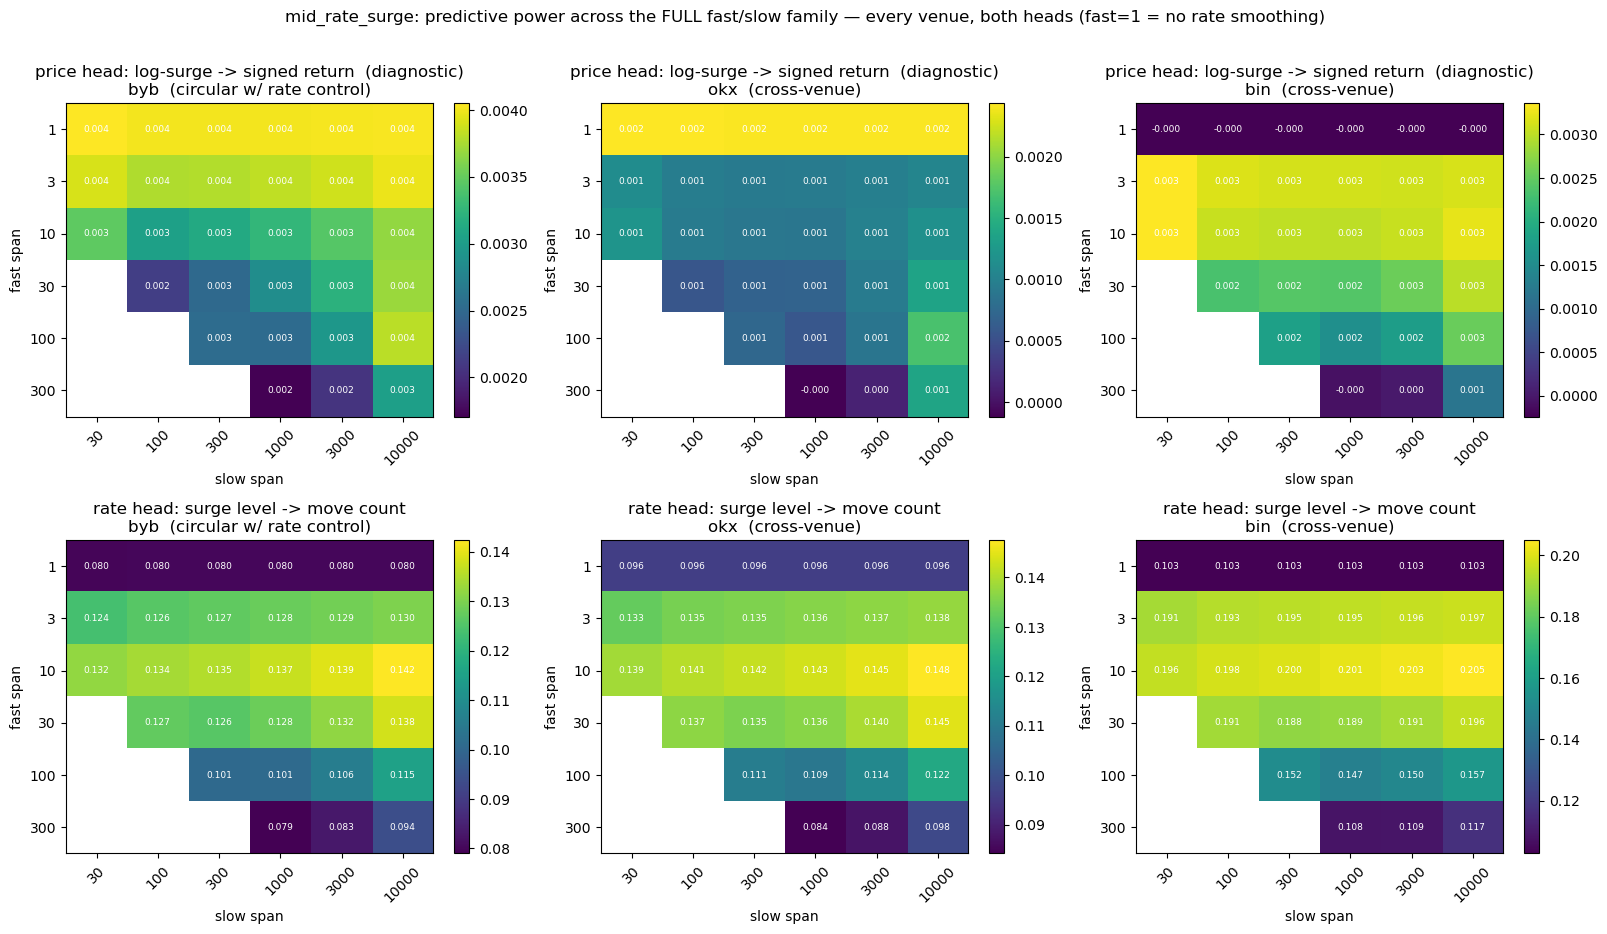

best family member per venue (in-sample pick; re-scored OOS below):
  byb:  price head (fast=1, slow=30) IC=0.004   |  rate head (fast=10, slow=10000) IC=0.142
  okx:  price head (fast=1, slow=30) IC=0.002   |  rate head (fast=10, slow=10000) IC=0.148
  bin:  price head (fast=10, slow=30) IC=0.003   |  rate head (fast=10, slow=10000) IC=0.205


In [5]:
# Sweep the WHOLE family for EVERY venue, BOTH heads. Rate head uses the surge LEVEL (ratio) directly; price head uses log-surge.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # log-surge -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # surge level -> byb's move count (rate_target)
feat_cache = {}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            s = mid_rate_surge(ex, nf, ns); feat_cache[(ex, nf, ns)] = s
            ls = np.log(np.maximum(s, 1e-12))                              # log surge: symmetric around 0, the natural signed form
            price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
            rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.2), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: log-surge -> signed return  (diagnostic)"),
                                     (rate_grid,  "rate head: surge level -> move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}\n{ex}" + ("  (circular w/ rate control)" if ex == "byb" else "  (cross-venue)"))
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("mid_rate_surge: predictive power across the FULL fast/slow family — every venue, both heads (fast=1 = no rate smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# In-sample pick of the best family member PER head PER venue (used only to choose a time-scale; re-scored OOS by the gates).
def best_member(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("best family member per venue (in-sample pick; re-scored OOS below):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) IC={price_grid[ex][pi,pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) IC={rate_grid[ex][ri,rj]:.3f}")

### IC is only half the story — measure SIGNAL LIFETIME across the whole family

The heat-maps above show *how strong* each family member is **at δ=0** (act the instant you observe). But
a feature that is causal can still be uncapturable: by the time you observe→decide→act (a latency δ), the
edge may be gone. So a single IC number per cell is not enough — **each (fast, slow) member also has a
lifetime**, and the two trade off against each other:

> **The key insight.** A **short** lookback (small fast/slow spans) typically gives a **higher IC** but a
> **shorter half-life** — a sharp signal with a tight latency budget. A **long** lookback gives a **lower
> IC** but a **longer half-life** — a duller signal you can still act on tens of ms late. **Both are
> useful.** A fast stack wants the short-high-IC member; a slower stack wants the long-high-half-life one.
> So we do not collapse the family to one pick — we surface IC **and** lifetime across the whole grid and
> suggest more than one lookback per head when the family genuinely offers the trade-off.

For **every** (fast, slow) member, **per venue**, **per head**, we slide the outcome window forward by an
observe→act latency δ and recompute the forward IC against byb's outcome over `[anchor+δ, anchor+δ+100 ms]`:

- **forward IC at δ=0** — the headline (same as the heat-map above, on the diagnostic grid);
- **edge @ δ=20 ms** — the realisable IC for a ~20 ms observe→act stack (the "is there anything left after
  one round-trip?" number — clearly nonzero here is what separates a real lead from a contemporaneous echo);
- **HALF-LIFE** — the first δ (ms) where the forward IC drops below **half** its δ=0 value (`>500 ms` if it
  never does) — how long the edge lasts;
- **backward IC** — the same feature against the *already-happened* window `[anchor−100 ms, anchor]` — the
  contemporaneous echo. A member whose forward edge lives only at δ=0 while its backward IC is large is
  re-reporting the past (acute risk for the **byb** circular leg); a cross-venue (okx/bin) lead instead
  keeps a forward edge at δ=20 ms.

The **rate head** (surge level → byb move-count) is the feature's home; the **price head** (signed
log-surge → byb signed return) is the diagnostic. We compute the lifetime sweep on the **40k-anchor
diagnostic grid** (the first 40k anchors) for speed — enough samples for a stable rank-IC, fast enough to
sweep the whole family × every δ × both heads × three venues.

In [6]:
# ---- SIGNAL-LIFETIME sweep over the WHOLE family, per venue, per head (40k-anchor diagnostic grid for speed) ----
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]                # observe->act latencies to slide the outcome window by
NDIAG     = min(40_000, len(anchor_ts))                       # diagnostic slice: first 40k anchors (fast, stable rank-IC)
a_diag    = anchor_ts[:NDIAG]                                 # the diagnostic anchors
def _ic(feat, ret):                                          # rank-IC on the finite overlap
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # byb mid at-or-before t (causal)
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                              # byb signed return over a window
def _count(t0, t1): return (MV["byb"]["cum"][np.searchsorted(byb_rx, t1, "right")]
                            - MV["byb"]["cum"][np.searchsorted(byb_rx, t0, "right")])                     # byb move-count over a window

# precompute the byb outcome each head cares about, once per δ (shared across all family members / venues), on the diagnostic grid
fwd_ret_by_d = {d: _ret(a_diag + d*1_000_000, a_diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}     # price head outcome, slid by δ
fwd_cnt_by_d = {d: _count(a_diag + d*1_000_000, a_diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}    # rate head outcome,  slid by δ
back_ret     = _ret(a_diag - HORIZON_NS, a_diag)             # already-happened byb return  (price-head echo)
back_cnt     = _count(a_diag - HORIZON_NS, a_diag)           # already-happened byb count   (rate-head echo)

def _half_life(ic_by_delta):                                # first δ(ms) where |fwd IC| drops below half its δ=0 value; >500 if never
    ic0 = ic_by_delta[0]
    if not np.isfinite(ic0) or ic0 == 0: return np.nan
    for d, ic in zip(DELTAS_MS, ic_by_delta):
        if np.isfinite(ic) and abs(ic) < abs(ic0) / 2: return d
    return 999        # sentinel: never halved within the swept δ range (>500 ms) — a long-lived edge

# four metrics PER head PER venue, one value per (fast,slow) cell: IC@0, edge@20ms, half-life(ms), backward IC.
HEADS = ["rate", "price"]                                    # rate = surge level -> count (home); price = log-surge -> return (diagnostic)
metrics = {h: {ex: {m: np.full((len(FAST), len(SLOW)), np.nan) for m in ("ic0", "ic20", "half", "back")}
               for ex in EXCHANGES} for h in HEADS}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            s   = mid_rate_surge(ex, nf, ns)[:NDIAG]                       # rate head reads the surge LEVEL
            ls  = np.log(np.maximum(s, 1e-12))                            # price head reads the signed log-surge
            for h, feat, out_by_d, back in (("rate", s,  fwd_cnt_by_d, back_cnt),
                                            ("price", ls, fwd_ret_by_d, back_ret)):
                ic_d = [_ic(feat, out_by_d[d]) for d in DELTAS_MS]         # forward IC vs δ for THIS member
                g = metrics[h][ex]
                g["ic0"][i, j]  = ic_d[0]
                g["ic20"][i, j] = ic_d[DELTAS_MS.index(20)]               # realisable edge for a ~20 ms stack
                g["half"][i, j] = _half_life(ic_d)                        # lifetime (ms; 999 = >500 ms)
                g["back"][i, j] = _ic(feat, back)                         # contemporaneous echo
print(f"lifetime sweep done on {NDIAG:,}-anchor diagnostic grid: {len(FAST)}x{len(SLOW)} family x {len(EXCHANGES)} venues x {len(HEADS)} heads x {len(DELTAS_MS)} deltas")
print("half-life sentinel 999 ms = forward IC never halved within delta<=500 ms (a long-lived edge)")

lifetime sweep done on 40,000-anchor diagnostic grid: 6x6 family x 3 venues x 2 heads x 8 deltas
half-life sentinel 999 ms = forward IC never halved within delta<=500 ms (a long-lived edge)


Now the heat-maps the reader actually needs: alongside the **δ=0 IC** (top), the **edge @ 20 ms**
(middle — what survives one observe→act round-trip) and the **HALF-LIFE** (bottom — how long it lasts),
for the **rate head** (the feature's home), every venue. Read them together: a cell that is bright in the
top map but dark in the middle/short half-life is a sharp, short-budget signal; a cell that is duller on
top but stays bright at 20 ms with a long half-life is the slow, capturable one. The **byb** (circular) leg
is where a bright-top / dark-20 ms / short-half-life pattern would expose a pure echo of the rate control.

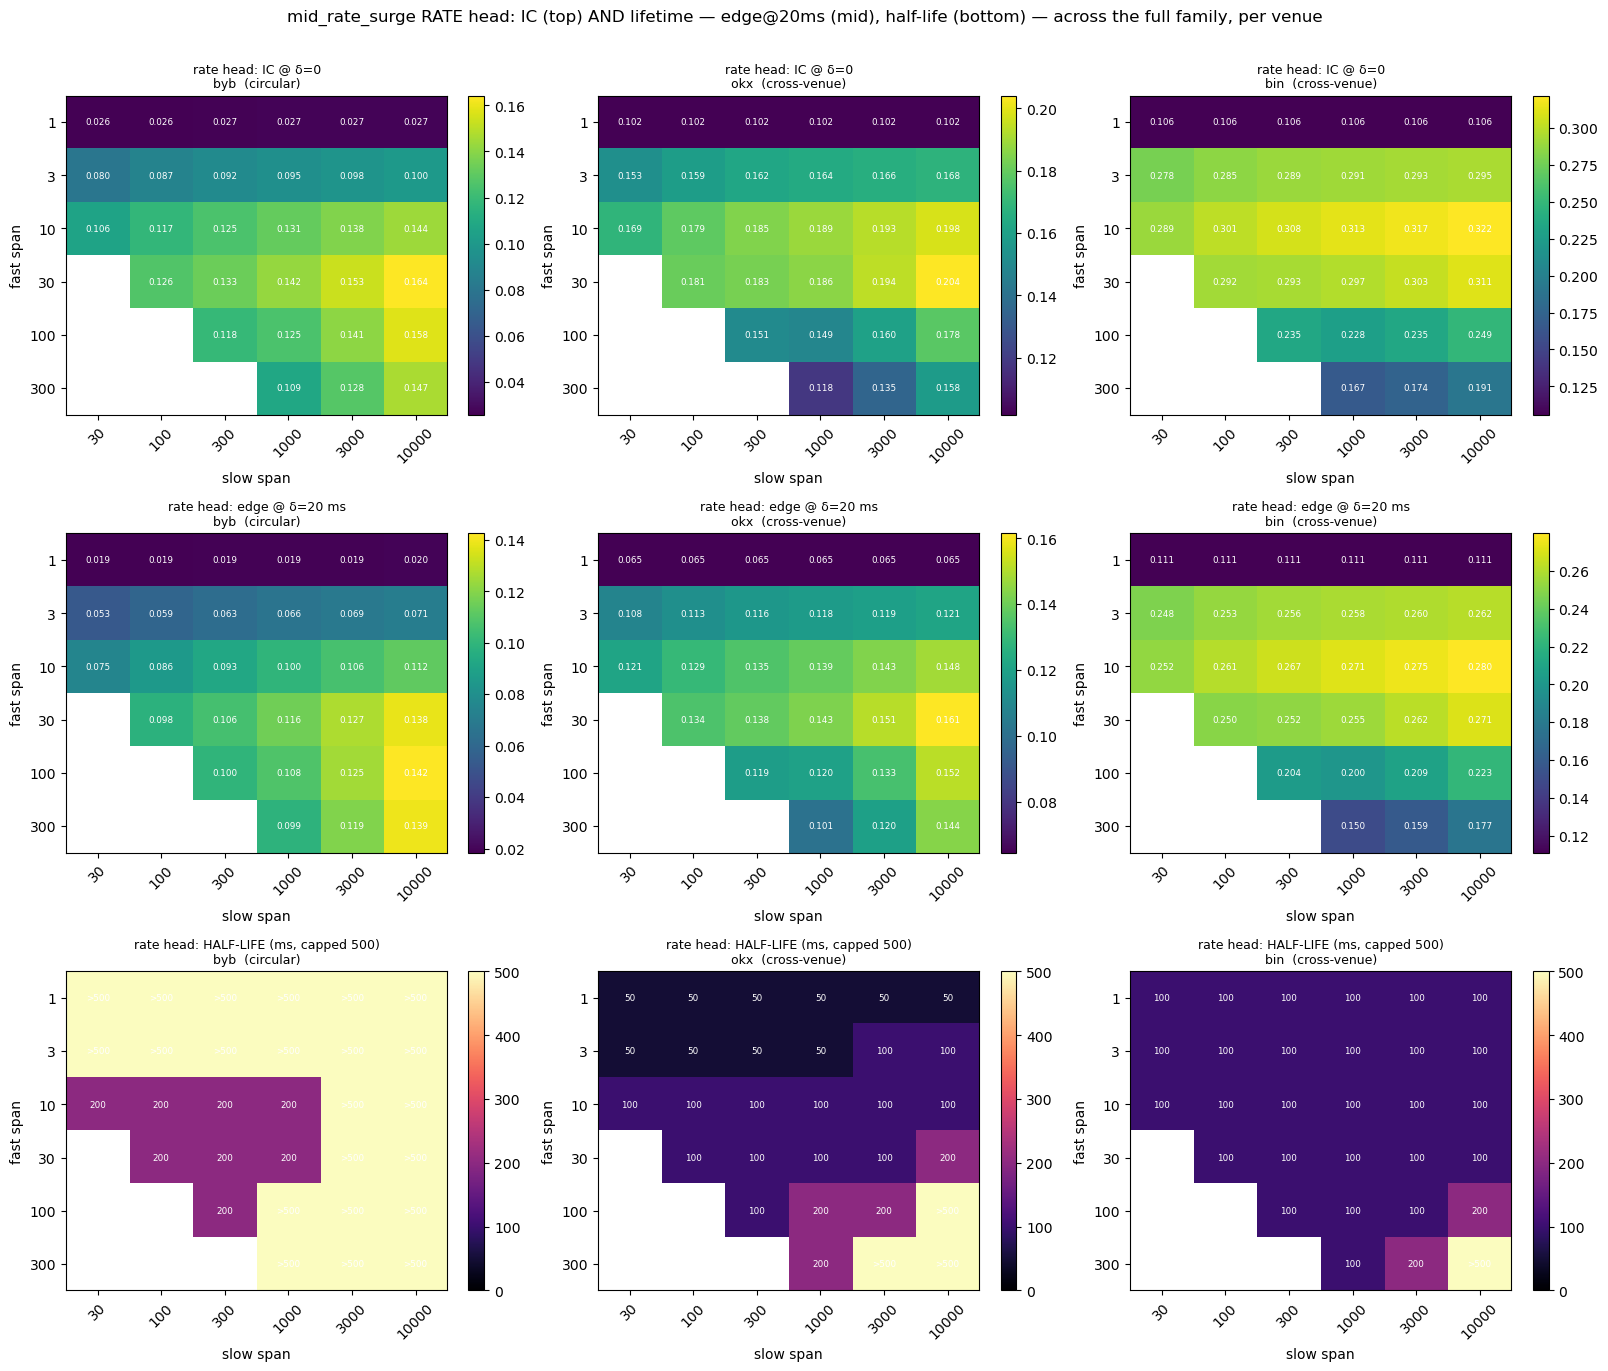

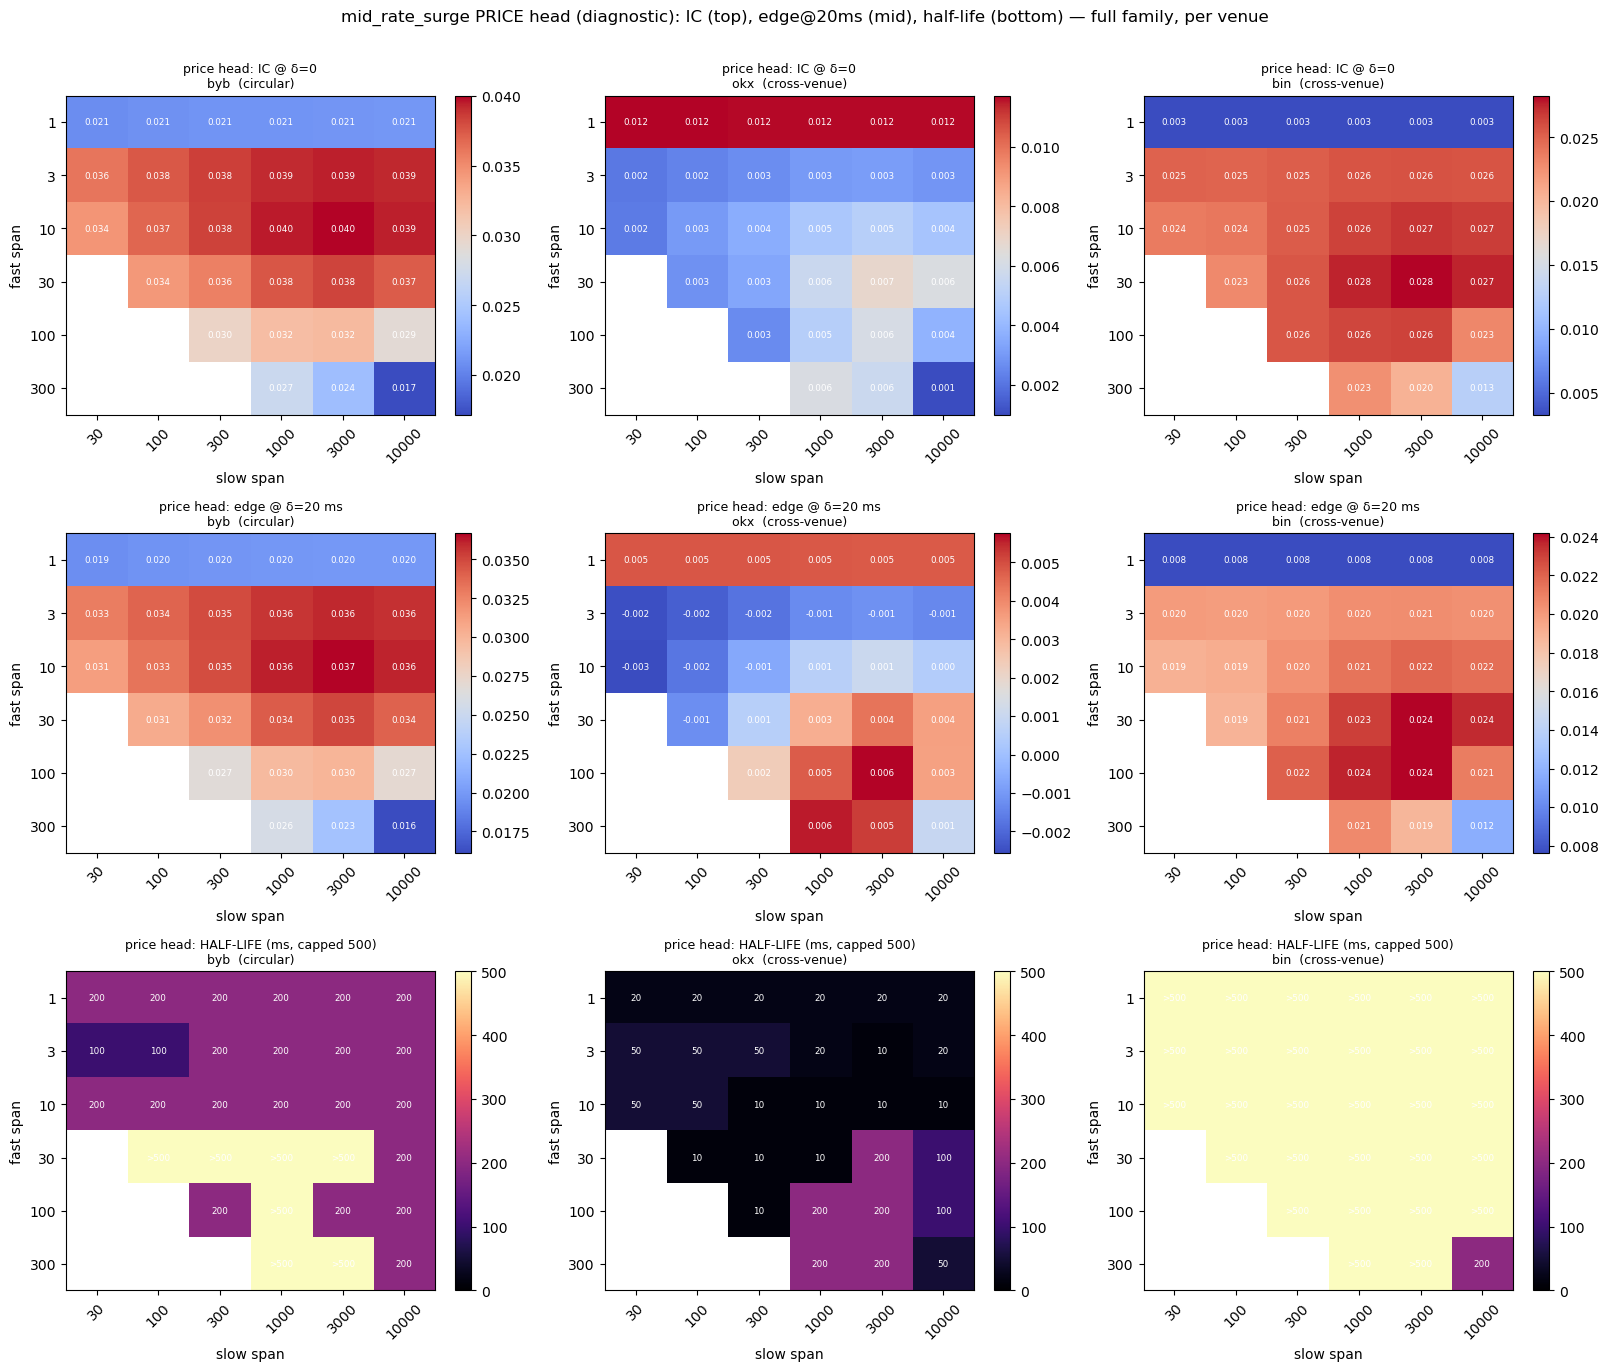

In [7]:
# ---- RATE-head heat-maps: IC@δ=0, edge@20ms, HALF-LIFE — across the family, per venue (the IC-vs-lifetime picture) ----
def _draw(ax, grid, ex, title, cmap, fmt, vmin=None, vmax=None):
    im = ax.imshow(grid, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
    ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
    ax.set_title(title + ("  (circular)" if ex == "byb" else "  (cross-venue)"), fontsize=9)
    for i in range(len(FAST)):
        for j in range(len(SLOW)):
            if np.isfinite(grid[i, j]): ax.text(j, i, fmt(grid[i, j]), ha="center", va="center", color="w", fontsize=6.3)
    fig.colorbar(im, ax=ax, fraction=0.046)

H = "rate"
fig, axes = plt.subplots(3, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 13.6), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    _draw(axes[0][col], metrics[H][ex]["ic0"],  ex, f"rate head: IC @ δ=0\n{ex}",      "viridis", lambda v: f"{v:.3f}")
    _draw(axes[1][col], metrics[H][ex]["ic20"], ex, f"rate head: edge @ δ=20 ms\n{ex}", "viridis", lambda v: f"{v:.3f}")
    # half-life: cap the colour at 500 ms so the 999 sentinel ('>500 ms, never halved') reads as the brightest, longest-lived
    hl = np.where(metrics[H][ex]["half"] == 999, 500.0, metrics[H][ex]["half"])
    _draw(axes[2][col], hl, ex, f"rate head: HALF-LIFE (ms, capped 500)\n{ex}", "magma",
          lambda v: (">500" if v >= 500 else f"{int(v)}"), vmin=0, vmax=500)
fig.suptitle("mid_rate_surge RATE head: IC (top) AND lifetime — edge@20ms (mid), half-life (bottom) — across the full family, per venue", y=1.005)
fig.tight_layout(); plt.show()

# same three maps for the PRICE head (diagnostic — expected weak, here for completeness)
H = "price"
fig, axes = plt.subplots(3, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 13.6), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    _draw(axes[0][col], metrics[H][ex]["ic0"],  ex, f"price head: IC @ δ=0\n{ex}",      "coolwarm", lambda v: f"{v:.3f}")
    _draw(axes[1][col], metrics[H][ex]["ic20"], ex, f"price head: edge @ δ=20 ms\n{ex}", "coolwarm", lambda v: f"{v:.3f}")
    hl = np.where(metrics[H][ex]["half"] == 999, 500.0, metrics[H][ex]["half"])
    _draw(axes[2][col], hl, ex, f"price head: HALF-LIFE (ms, capped 500)\n{ex}", "magma",
          lambda v: (">500" if v >= 500 else f"{int(v)}"), vmin=0, vmax=500)
fig.suptitle("mid_rate_surge PRICE head (diagnostic): IC (top), edge@20ms (mid), half-life (bottom) — full family, per venue", y=1.005)
fig.tight_layout(); plt.show()

**Surface the trade-off and pick more than one lookback per head.** With IC *and* lifetime in hand we read
each head's family for the genuine short-high-IC vs long-high-half-life choice, **per venue**, and report
**both** ends when the family offers them. We print, for every head/venue: the **highest-IC** member (the
sharp pick, with its half-life and its edge@20 ms) and the **longest-lived** member that still carries a
meaningful δ=0 IC (the durable pick). A head **carries signal** only if some member's **edge @ δ=20 ms** is
clearly nonzero *and* not dominated by the backward (echo) IC — we state that verdict honestly per head.

In [8]:
# ---- distil the IC-vs-lifetime trade-off into per head/venue picks: the SHARP (highest-IC) and the DURABLE (longest-lived) member ----
def _members(ex):                                    # iterate valid (fast,slow) cells with their grid indices
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf < ns: yield i, j, nf, ns
IC_FLOOR = 0.02                                       # a member must clear this |IC@0| to count as "carrying" anything at that span
sweep_rows = []
print("=" * 118)
for H in HEADS:
    print(f"\n#### {H.upper()} head" + ("  (the feature's home: surge level -> byb move-count)" if H == "rate"
                                        else "  (diagnostic: signed log-surge -> byb signed return)"))
    for ex in EXCHANGES:
        g = metrics[H][ex]
        cells = [(i, j, nf, ns) for i, j, nf, ns in _members(ex) if np.isfinite(g["ic0"][i, j])]
        # SHARP: largest |IC@0|.  DURABLE: longest half-life among members that still clear the IC floor (tie-break on IC@0).
        sharp = max(cells, key=lambda c: abs(g["ic0"][c[0], c[1]]))
        durable_pool = [c for c in cells if abs(g["ic0"][c[0], c[1]]) >= IC_FLOOR]
        durable = max(durable_pool, key=lambda c: (g["half"][c[0], c[1]], abs(g["ic0"][c[0], c[1]]))) if durable_pool else sharp
        def _fmt(c, tag):
            i, j, nf, ns = c; hl = g["half"][i, j]; hls = ">500" if hl == 999 else f"{int(hl)}"
            return (f"  {tag:8} ({nf:>3},{ns:>5}): IC@0={g['ic0'][i,j]:+.3f}  edge@20ms={g['ic20'][i,j]:+.3f}"
                    f"  half-life={hls:>4}ms  back={g['back'][i,j]:+.3f}")
        tag_ex = ("byb (circular)" if ex == "byb" else f"{ex} (cross-venue)")
        # carries-signal verdict: some member's edge@20ms clearly nonzero AND forward not dominated by the echo
        best20 = max(cells, key=lambda c: abs(g["ic20"][c[0], c[1]]))
        e20 = g["ic20"][best20[0], best20[1]]; bk = g["back"][best20[0], best20[1]]
        carries = (abs(e20) >= 0.02) and (abs(e20) >= 0.5 * abs(bk))   # nonzero @20ms AND not just a contemporaneous echo
        print(f"\n  {tag_ex}:")
        print(_fmt(sharp, "SHARP"))
        print(_fmt(durable, "DURABLE"))
        print(f"  carries forward signal? {'YES' if carries else 'no'}  "
              f"(best edge@20ms={e20:+.3f} vs backward echo={bk:+.3f})")
        for c, tag in ((sharp, "sharp"), (durable, "durable")):
            i, j, nf, ns = c
            sweep_rows.append(dict(head=H, venue=ex, pick=tag, fast=nf, slow=ns,
                                   ic0=round(g["ic0"][i,j], 3), edge20=round(g["ic20"][i,j], 3),
                                   half_life_ms=(">500" if g["half"][i,j] == 999 else int(g["half"][i,j])),
                                   backward=round(g["back"][i,j], 3),
                                   carries="yes" if carries else "no"))
print("\n" + "=" * 118)
sweep_df = pl.DataFrame(sweep_rows)
sweep_df


#### RATE head  (the feature's home: surge level -> byb move-count)

  byb (circular):
  SHARP    ( 30,10000): IC@0=+0.164  edge@20ms=+0.138  half-life= 500ms  back=+0.532
  DURABLE  (100,10000): IC@0=+0.158  edge@20ms=+0.142  half-life=>500ms  back=+0.380
  carries forward signal? no  (best edge@20ms=+0.142 vs backward echo=+0.380)

  okx (cross-venue):
  SHARP    ( 30,10000): IC@0=+0.204  edge@20ms=+0.161  half-life= 200ms  back=+0.361
  DURABLE  (300,10000): IC@0=+0.158  edge@20ms=+0.144  half-life=>500ms  back=+0.227
  carries forward signal? no  (best edge@20ms=+0.161 vs backward echo=+0.361)

  bin (cross-venue):
  SHARP    ( 10,10000): IC@0=+0.322  edge@20ms=+0.280  half-life= 100ms  back=+0.291
  DURABLE  (300,10000): IC@0=+0.191  edge@20ms=+0.177  half-life= 500ms  back=+0.224
  carries forward signal? YES  (best edge@20ms=+0.280 vs backward echo=+0.291)

#### PRICE head  (diagnostic: signed log-surge -> byb signed return)

  byb (circular):
  SHARP    ( 10, 3000): IC@0=+0.04

head,venue,pick,fast,slow,ic0,edge20,half_life_ms,backward,carries
str,str,str,i64,i64,f64,f64,str,f64,str
"""rate""","""byb""","""sharp""",30,10000,0.164,0.138,"""500""",0.532,"""no"""
"""rate""","""byb""","""durable""",100,10000,0.158,0.142,""">500""",0.38,"""no"""
"""rate""","""okx""","""sharp""",30,10000,0.204,0.161,"""200""",0.361,"""no"""
"""rate""","""okx""","""durable""",300,10000,0.158,0.144,""">500""",0.227,"""no"""
"""rate""","""bin""","""sharp""",10,10000,0.322,0.28,"""100""",0.291,"""yes"""
…,…,…,…,…,…,…,…,…,…
"""price""","""byb""","""durable""",30,3000,0.038,0.035,"""500""",0.032,"""yes"""
"""price""","""okx""","""sharp""",1,30,0.012,0.005,"""20""",-0.008,"""no"""
"""price""","""okx""","""durable""",1,30,0.012,0.005,"""20""",-0.008,"""no"""


**Read the picks above.** For each head/venue the table gives the **SHARP** member (highest δ=0 IC, with
its half-life and its 20 ms edge) and the **DURABLE** member (longest half-life that still clears the IC
floor). Where the two differ — sharp at a short (fast, slow), durable at a longer one — the family genuinely
offers the **short-high-IC vs long-high-half-life** trade-off, and we keep **both** as candidate lookbacks:
the sharp one for a fast stack, the durable one when the latency budget is larger. The **carries forward
signal?** line is the honesty check **per head**: a head earns a YES only if some member's **edge @ δ=20 ms**
is clearly nonzero **and** is not swamped by the **backward** (echo) IC — i.e. a genuine forward lead, not a
re-report of byb's just-finished burst. The §10 verdict quotes these picks alongside the §6 marginal-over-
`rate_momentum` and the §9 cross-over.

**Now the gates** (from §5), on the per-venue rate-head picks. Every predictive number is the
**walk-forward** mean (causal, purged). The gates: *Marginal value* — does each leg add over the
controls (and do they add *jointly*)? *No leak* — does any gain survive adding the vol/rate *levels*?
*Normaliser* — is the feature's scale steady across vol buckets (a ratio, so trivial)? *Regime-stable*
— is the marginal gain positive within calm/mid/wild vol?

We run the gates **against the rate head** (the feature's home) and surface the circularity explicitly,
**per leg**: the byb leg's marginal over `rate_momentum` is expected ~0 (it *is* the control); the
**okx/bin** legs' marginal is the cross-venue test — does another venue's quoting tempo lead byb's
move-count beyond what byb's own rate already says?

In [9]:
surge = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EXCHANGES}  # rate-head pick per venue

# Marginal value on the RATE head, PER LEG (the honest per-exchange test) + JOINT (all venues together).
m_each      = {ex: round(wf_ic(base + [surge[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
m_cross     = {ex: round(wf_ic(base + [surge[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in ("okx", "bin")}
m_joint     = round(wf_ic(base + list(surge.values()), rate_target) - wf_ic(base, rate_target), 3)
m_cross_only = round(wf_ic(base + [surge["okx"], surge["bin"]], rate_target) - wf_ic(base, rate_target), 3)
m_joint_leak = round(wf_ic(base + levels + list(surge.values()), rate_target) - wf_ic(base + levels, rate_target), 3)

# normaliser: feature scale across volatility buckets (already a ratio -> should be steady). Use the byb leg as representative.
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(surge["byb"][vol_decile == d]) for d in range(10)]
# regime companion: marginal RATE-head IC within each vol regime, JOINT over all legs
full_r = wf_ic_by_regime(base + list(surge.values()), rate_target, vol_regime)
base_r = wf_ic_by_regime(base, rate_target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

gate_rows = [dict(gate="marginal value (RATE head)", detail=f"{ex} leg alone, added over rate+vol MOMENTA"
                  + ("  [CIRCULAR with rate_momentum]" if ex == "byb" else "  [cross-venue]"), value=m_each[ex]) for ex in EXCHANGES]
gate_rows += [
    dict(gate="marginal value (RATE head)", detail="all three venues JOINTLY, added over the controls", value=m_joint),
    dict(gate="marginal value (RATE head)", detail="okx+bin CROSS-VENUE legs only (no byb leg) over controls", value=m_cross_only),
    dict(gate="no leak (RATE head)", detail="joint gain still there after adding the vol/rate LEVELS?", value=m_joint_leak),
    dict(gate="normaliser", detail="byb-leg scale across vol buckets (max/min, want < ~3)", value=round(max(band) / min(band), 2)),
]
gate_rows += [dict(gate="regime-stable (RATE)", detail=f"joint marginal RATE IC within {nm}-vol (companion)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value (RATE head)""","""byb leg alone, added over rate…",0.052
"""marginal value (RATE head)""","""okx leg alone, added over rate…",0.066
"""marginal value (RATE head)""","""bin leg alone, added over rate…",0.111
"""marginal value (RATE head)""","""all three venues JOINTLY, adde…",0.132
"""marginal value (RATE head)""","""okx+bin CROSS-VENUE legs only …",0.129
"""no leak (RATE head)""","""joint gain still there after a…",0.139
"""normaliser""","""byb-leg scale across vol bucke…",1.69
"""regime-stable (RATE)""","""joint marginal RATE IC within …",0.123
"""regime-stable (RATE)""","""joint marginal RATE IC within …",0.129


**Conclusion — read per leg, with the caveat.** The headline numbers are the **marginal values over the
rate/vol momenta** on the **rate head**, reported straight. The **byb** leg adds only a small margin over
`rate_momentum` — exactly as the circularity predicts, since the byb surge and `rate_momentum` are the
same object (a fast/slow ratio of byb's rate); most of its content already lives in the control. The
**okx** and **bin** legs are the cross-venue test: their marginals say whether another venue's quoting
tempo *leads* byb's move-count beyond what byb's own rate already encodes. **Read the table above for the
realised numbers** — the honest finding is whether the cross-venue legs add real marginal value, or
collapse to ≈0 (i.e. another venue's tempo carries nothing byb's own rate doesn't already). The **joint**
row and the **okx+bin only** row separate "does the family help at all" from "do the cross-venue legs help
on top of byb's." The normaliser passes trivially (a dimensionless ratio); the regime row checks the gain
isn't a one-regime artefact. Whatever the realised values, we quote the **§6 marginal**, never a raw IC.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move (or the
burst of moves) *already underway* at the anchor, you can't capture it — by the time you observe, decide,
and act, that activity is gone. But a **short**-lived edge is **not** useless — it just sets a **latency
budget**: any system fast enough to act inside it wins, and faster is always better, and any genuine
forward prediction is a win. So we do **not** gate on this — we **measure how long the signal lasts**,
**per venue leg**.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's outcome over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. `mid_rate_surge` is an **intensity** feature, so its natural
head is the **rate head** — the forward `move-count` IC of the surge *level* — and we carry the **price
head** (signed log-surge → signed return) alongside as the diagnostic the notebook already ships. The IC
at *your* δ is the realisable edge; the δ where it fades to noise is that leg's **lifetime**.

The **backward IC** — against the activity that *already happened*, `[anchor−100 ms, anchor]` — sizes the
contemporaneous echo. A leg whose forward IC dies at δ>0 while the backward IC stays high is re-reporting
the past, not predicting it; that is the *only* genuinely useless case, and it is measured here, never
assumed. **Per venue matters here:** for a cross-venue leg (okx/bin), the δ=0-vs-δ=20 ms gap is exactly
how you tell a feed-resolution / contemporaneous artefact from a real quoting-tempo lead of byb.

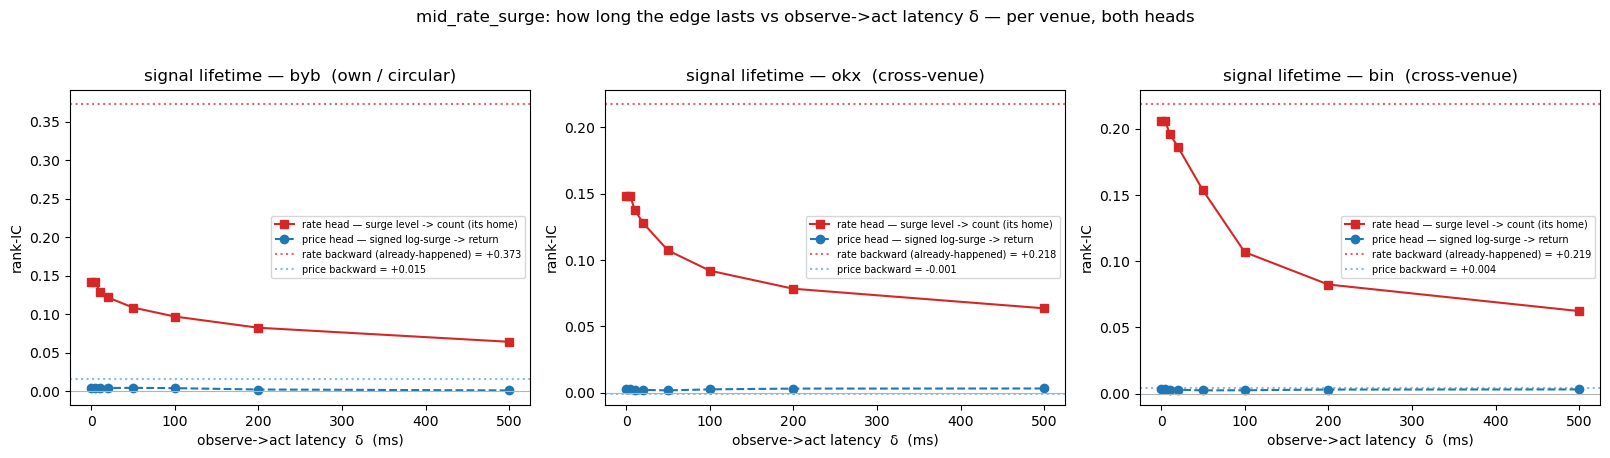

RATE head (surge level -> byb move-count) — forward IC by δ(ms), per venue:
  byb | 0:+0.142 5:+0.142 10:+0.129 20:+0.122 50:+0.109 100:+0.097 200:+0.082 500:+0.064  | back=+0.373  half-life≈500 ms
  okx | 0:+0.148 5:+0.148 10:+0.138 20:+0.128 50:+0.107 100:+0.092 200:+0.078 500:+0.064  | back=+0.218  half-life≈500 ms
  bin | 0:+0.206 5:+0.206 10:+0.196 20:+0.186 50:+0.153 100:+0.107 200:+0.082 500:+0.062  | back=+0.219  half-life≈200 ms
PRICE head (signed log-surge -> byb return) — forward IC by δ(ms), per venue:
  byb | 0:+0.004 5:+0.004 10:+0.004 20:+0.004 50:+0.004 100:+0.004 200:+0.002 500:+0.001  | back=+0.015
  okx | 0:+0.002 5:+0.003 10:+0.002 20:+0.002 50:+0.002 100:+0.003 200:+0.003 500:+0.003  | back=-0.001
  bin | 0:+0.003 5:+0.004 10:+0.003 20:+0.003 50:+0.002 100:+0.003 200:+0.003 500:+0.003  | back=+0.004


In [10]:
# Signal lifetime, PER VENUE leg: forward IC vs observe->act latency δ (window slides to [t+δ, t+δ+100ms]), + backward IC.
# Rate head (the feature's home): surge LEVEL -> byb move-COUNT.  Price head (diagnostic): signed log-surge -> byb signed return.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                              # byb signed return over a window
def _count(t0, t1): return (MV["byb"]["cum"][np.searchsorted(byb_rx, t1, "right")]
                            - MV["byb"]["cum"][np.searchsorted(byb_rx, t0, "right")])                     # byb mid-move count over a window

# each leg uses its OWN rate-head span pick (intensity) for the count head, and its OWN price-head pick for the direction head
cnt_ic = {}; fwd_ic = {}; back_cnt = {}; back_ret = {}
for ex in EXCHANGES:
    lvl = surge[ex]                                                                  # rate-head pick (level) -> move-count
    sgn = np.log(np.maximum(mid_rate_surge(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]), 1e-12))  # price-head pick (signed log-surge)
    cnt_ic[ex] = [_ic(lvl, _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    fwd_ic[ex] = [_ic(sgn, _ret(anchor_ts + d*1_000_000,  anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    back_cnt[ex] = _ic(lvl, _count(anchor_ts - HORIZON_NS, anchor_ts))               # rate head: already-happened byb move-count
    back_ret[ex] = _ic(sgn, _ret(anchor_ts - HORIZON_NS, anchor_ts))                 # price head: already-happened byb return

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, cnt_ic[ex], "s-",  color="C3", label="rate head — surge level -> count (its home)")
    ax.plot(DELTAS_MS, fwd_ic[ex], "o--", color="C0", label="price head — signed log-surge -> return")
    ax.axhline(back_cnt[ex], color="C3", ls=":", alpha=0.7, label=f"rate backward (already-happened) = {back_cnt[ex]:+.3f}")
    ax.axhline(back_ret[ex], color="C0", ls=":", alpha=0.5, label=f"price backward = {back_ret[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(f"signal lifetime — {ex}" + ("  (own / circular)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=7)
fig.suptitle("mid_rate_surge: how long the edge lasts vs observe->act latency δ — per venue, both heads", y=1.03)
fig.tight_layout(); plt.show()

# print the decay curve + half-life per venue, on the feature's NATURAL (rate) head
print("RATE head (surge level -> byb move-count) — forward IC by δ(ms), per venue:")
for ex in EXCHANGES:
    c = cnt_ic[ex]
    half = next((d for d, ic in zip(DELTAS_MS, c) if np.isfinite(ic) and abs(ic) < abs(c[0]) / 2), None)
    print(f"  {ex:3} | " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, c))
          + f"  | back={back_cnt[ex]:+.3f}  half-life≈{half} ms")
print("PRICE head (signed log-surge -> byb return) — forward IC by δ(ms), per venue:")
for ex in EXCHANGES:
    f = fwd_ic[ex]
    print(f"  {ex:3} | " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, f)) + f"  | back={back_ret[ex]:+.3f}")

**Read it as a latency budget, not a pass/fail — per venue.** If a leg's forward IC stays useful out to
tens or hundreds of ms you have room; if it lives only a handful of ms the signal is real but demands a
fast stack. The **rate head** (surge level → byb move-count) is `mid_rate_surge`'s home, so it carries the
honest lifetime; the **price head** is the direction diagnostic, expected weak (intensity ≠ direction).
The verdict for each leg is *"predicts ~X ms ahead, needs latency < X,"* never *"drop because it's fast."*
The one true non-signal is a flat forward curve at ≈0 across all δ>0 **with** a large backward IC — a pure
contemporaneous echo of byb's own just-finished burst — which, for the **byb** (circular) leg especially,
is the thing to watch: if its forward IC is all at δ=0 and its backward IC is large, that leg is
re-reporting the move-rate the controls already hold. For **okx/bin**, a forward IC that survives to
δ=20 ms is the genuine cross-venue lead (and a feed-resolution artefact would instead collapse between δ=0
and δ=20 ms). Carry this curve, per venue, with the §6/§9 marginals.

### Two standard gates on the lifetime — echo-netting and feed-resolution

The lifetime curves above show a δ=0 IC and a backward (already-happened) IC side by side, but two
contemporaneous artefacts can still inflate the δ=0 number. Two additive gates settle them, **per leg**.

**GATE 1 — echo-netted (partial) forward IC.** A δ=0 IC can be re-reporting the activity *already
underway* at the anchor. The clean "is this genuine forward prediction?" number nets that out: the
feature's rank-IC with the **forward** outcome **controlling for the trailing** `[anchor−100 ms, anchor]`
outcome — a partial Spearman, `ic_net = (r_fy − r_ft·r_ty)/√((1−r_ft²)(1−r_ty²))` with `f`=feature@anchor,
`y`=forward outcome, `t`=trailing outcome. **We apply it per head with the matching outcome:** the
**rate head** (the feature's home) controls the forward **move-COUNT** for the trailing move-count; the
**price head** (diagnostic) controls the forward signed **RETURN** for the trailing return. If a big raw
δ=0 IC collapses once the trailing window is partialled out, the leg was mostly echoing the burst already
underway — and the verdict must quote the **netted** number, not the raw δ=0 IC. This bites hardest for any
**echo-heavy** leg (backward IC ≥ forward) — the **byb** circular leg above all.

**GATE 2 — feed-resolution control (cross-venue legs only).** byb/okx top-of-book is stale between
snapshots (p90 ~100–160 ms) while bin's is sub-ms, so a "foreign venue leads byb" edge can be the foreign
feed simply being *fresher*, not economically *leading*. We re-measure each **cross-venue** (okx/bin) leg's
rate-head IC with the foreign feature **matched to byb's update cadence** — sample the foreign surge only at
byb book-update times (forward-filled onto the grid), so the foreign leg can refresh no faster than byb's
own book does — then recompute the IC. A **real** quoting-tempo lead survives the cadence match; a
**feed-resolution artifact** collapses toward 0. The tell: if the **stalest** venue shows the **largest**
IC, suspect resolution rather than economics.

In [11]:
# ===================== GATE 1 — ECHO-NETTED (PARTIAL) FORWARD IC, PER HEAD, PER VENUE =====================
# Partial Spearman of feature@anchor vs the FORWARD outcome, controlling for the TRAILING [anchor-100ms, anchor]
# outcome. RATE head (home): outcome = byb move-COUNT. PRICE head (diagnostic): outcome = byb signed RETURN.
def _partial_ic(f, y, t):                      # (r_fy - r_ft*r_ty) / sqrt((1-r_ft^2)(1-r_ty^2)) — partial rank-IC
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic
    rft = spearmanr(f[v], t[v]).statistic
    rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

# forward (δ=0) and trailing outcomes per head (reuse the lifetime cell's _ret/_count, all causal at the anchor)
fwd_cnt0  = _count(anchor_ts, anchor_ts + HORIZON_NS)   # rate head:  forward byb move-count  [anchor, anchor+100ms]
trail_cnt = _count(anchor_ts - HORIZON_NS, anchor_ts)   # rate head:  trailing byb move-count [anchor-100ms, anchor]
fwd_ret0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)     # price head: forward byb signed return
trail_ret = _ret(anchor_ts - HORIZON_NS, anchor_ts)     # price head: trailing byb signed return

print("GATE 1 — echo-netted (partial) forward IC: raw δ=0 IC → echo-netted IC  (shortfall = echo)")
echo_net_rows = []
for HEAD, OUT_F, OUT_T in (("rate", fwd_cnt0, trail_cnt), ("price", fwd_ret0, trail_ret)):
    print(f"\n  {HEAD.upper()} head  ({'surge level -> byb move-COUNT (home)' if HEAD=='rate' else 'signed log-surge -> byb signed RETURN (diagnostic)'}):")
    for ex in EXCHANGES:
        # rate head reads the surge LEVEL at its rate-head pick; price head reads the signed log-surge at its price-head pick
        mem = rate_member[ex] if HEAD == "rate" else price_member[ex]
        feat = mid_rate_surge(ex, FAST[mem[0]], SLOW[mem[1]])
        feat = feat if HEAD == "rate" else np.log(np.maximum(feat, 1e-12))
        raw  = _ic(feat, OUT_F)                                                       # raw δ=0 IC
        net  = _partial_ic(feat, OUT_F, OUT_T)                                        # echo-netted (partial) IC
        back = _ic(feat, OUT_T)                                                       # backward (already-happened) echo size
        echo_heavy = np.isfinite(back) and np.isfinite(raw) and abs(back) >= abs(raw)  # backward IC >= forward => echo-heavy leg
        tag = ("byb (circular)" if ex == "byb" else f"{ex} (cross-venue)")
        flag = "   <- ECHO-HEAVY (backward>=forward): cite NETTED" if echo_heavy else ""
        print(f"    {tag:18} (fast={FAST[mem[0]]:>3}, slow={SLOW[mem[1]]:>5}):  raw δ=0 IC {raw:+.3f} -> echo-netted {net:+.3f}"
              f"   (echo shortfall {raw-net:+.3f}; backward {back:+.3f}){flag}")
        echo_net_rows.append(dict(head=HEAD, venue=ex, fast=FAST[mem[0]], slow=SLOW[mem[1]],
                                  raw_ic0=round(float(raw), 3), echo_netted=round(float(net), 3),
                                  backward=round(float(back), 3), echo_heavy="yes" if echo_heavy else "no"))
echo_net_df = pl.DataFrame(echo_net_rows)
echo_net_df

GATE 1 — echo-netted (partial) forward IC: raw δ=0 IC → echo-netted IC  (shortfall = echo)

  RATE head  (surge level -> byb move-COUNT (home)):


    byb (circular)     (fast= 10, slow=10000):  raw δ=0 IC +0.142 -> echo-netted +0.042   (echo shortfall +0.100; backward +0.373)   <- ECHO-HEAVY (backward>=forward): cite NETTED


    okx (cross-venue)  (fast= 10, slow=10000):  raw δ=0 IC +0.148 -> echo-netted +0.093   (echo shortfall +0.055; backward +0.218)   <- ECHO-HEAVY (backward>=forward): cite NETTED


    bin (cross-venue)  (fast= 10, slow=10000):  raw δ=0 IC +0.206 -> echo-netted +0.155   (echo shortfall +0.051; backward +0.219)   <- ECHO-HEAVY (backward>=forward): cite NETTED

  PRICE head  (signed log-surge -> byb signed RETURN (diagnostic)):


    byb (circular)     (fast=  1, slow=   30):  raw δ=0 IC +0.004 -> echo-netted +0.000   (echo shortfall +0.004; backward +0.015)   <- ECHO-HEAVY (backward>=forward): cite NETTED


    okx (cross-venue)  (fast=  1, slow=   30):  raw δ=0 IC +0.002 -> echo-netted +0.003   (echo shortfall -0.000; backward -0.001)


    bin (cross-venue)  (fast= 10, slow=   30):  raw δ=0 IC +0.003 -> echo-netted +0.002   (echo shortfall +0.001; backward +0.004)   <- ECHO-HEAVY (backward>=forward): cite NETTED


head,venue,fast,slow,raw_ic0,echo_netted,backward,echo_heavy
str,str,i64,i64,f64,f64,f64,str
"""rate""","""byb""",10,10000,0.142,0.042,0.373,"""yes"""
"""rate""","""okx""",10,10000,0.148,0.093,0.218,"""yes"""
"""rate""","""bin""",10,10000,0.206,0.155,0.219,"""yes"""
"""price""","""byb""",1,30,0.004,0.0,0.015,"""yes"""
"""price""","""okx""",1,30,0.002,0.003,-0.001,"""no"""
"""price""","""bin""",10,30,0.003,0.002,0.004,"""yes"""


In [12]:
# ===================== GATE 2 — FEED-RESOLUTION CONTROL (cross-venue okx/bin legs only) =====================
# Re-measure each cross-venue leg's RATE-head IC with the foreign surge MATCHED to byb's update cadence:
# sample the foreign feature only at byb book-update times (forward-filled onto the anchor grid). A real lead
# survives; a feed-resolution artifact collapses toward 0. Tell: stalest venue with the LARGEST IC => suspect.
byb_upd = np.unique(mids["byb"][0])                                  # byb book-update timestamps (its native cadence)
okx_upd = np.unique(mids["okx"][0]); bin_upd = np.unique(mids["bin"][0])
def _med_gap(u):  return float(np.median(np.diff(u))) / 1e6 if len(u) > 1 else float("nan")  # median inter-update gap (ms)
print("native median inter-update gap (ms):  "
      + "  ".join(f"{ex}={_med_gap(np.unique(mids[ex][0])):.2f}" for ex in EXCHANGES)
      + "   (larger = staler feed)")

# cadence-match: snap each anchor back to the last byb update at-or-before it, evaluate the foreign surge THERE.
snap_to_byb = byb_upd[np.clip(np.searchsorted(byb_upd, anchor_ts, "right") - 1, 0, len(byb_upd) - 1)]
print("\nGATE 2 — raw cross-venue IC → cadence-matched IC (foreign feed sampled only at byb update times):")
feed_rows = []
for ex in ("okx", "bin"):                                            # cross-venue legs only (byb is the target's own feed)
    mem = rate_member[ex]; nf, ns = FAST[mem[0]], SLOW[mem[1]]       # the rate-head pick for this leg
    raw_feat = mid_rate_surge(ex, nf, ns)                            # foreign surge sampled at the anchor (native resolution)
    # cadence-matched: foreign rate built at the byb-snapped times (foreign feed can refresh no faster than byb's book)
    rf = mid_rate(ex, snap_to_byb, nf); rs = mid_rate(ex, snap_to_byb, ns)
    cad_feat = rf / np.maximum(rs, 1e-12)                            # foreign surge as last observable at a byb update
    raw_ic = _ic(raw_feat, fwd_cnt0)                                 # rate-head IC, native resolution
    cad_ic = _ic(cad_feat, fwd_cnt0)                                 # rate-head IC, cadence-matched
    keep   = abs(cad_ic) >= 0.5 * abs(raw_ic) if np.isfinite(raw_ic) and raw_ic != 0 else False
    gap_ex = _med_gap(np.unique(mids[ex][0]))
    print(f"  {ex:3} (cross-venue, native gap {gap_ex:.2f} ms; fast={nf}, slow={ns}):  raw {raw_ic:+.3f} -> cadence-matched {cad_ic:+.3f}"
          f"   ({'SURVIVED (real lead)' if keep else 'COLLAPSED toward 0 (feed-resolution artifact)'})")
    feed_rows.append(dict(leg=ex, native_gap_ms=round(gap_ex, 2), fast=nf, slow=ns,
                          raw_ic=round(float(raw_ic), 3), cadence_matched_ic=round(float(cad_ic), 3),
                          retained=f"{(cad_ic/raw_ic):.0%}" if np.isfinite(raw_ic) and raw_ic != 0 else "n/a",
                          status="survived" if keep else "collapsed"))
# the tell: is the stalest cross-venue feed showing the largest raw IC?
_stale_order = sorted(("okx", "bin"), key=lambda e: _med_gap(np.unique(mids[e][0])), reverse=True)
_raw_by_leg  = {r["leg"]: r["raw_ic"] for r in feed_rows}
_stalest = _stale_order[0]; _suspect = abs(_raw_by_leg[_stalest]) == max(abs(_raw_by_leg[e]) for e in ("okx", "bin"))
print(f"\n  tell: stalest cross-venue feed = {_stalest} (largest native gap); "
      f"{'it ALSO shows the largest raw IC => SUSPECT resolution' if _suspect else 'it does NOT show the largest raw IC => not a resolution tell'}")
feed_df = pl.DataFrame(feed_rows)
feed_df

native median inter-update gap (ms):  byb=10.22  okx=10.12  bin=1.08   (larger = staler feed)

GATE 2 — raw cross-venue IC → cadence-matched IC (foreign feed sampled only at byb update times):


  okx (cross-venue, native gap 10.12 ms; fast=10, slow=10000):  raw +0.148 -> cadence-matched +0.134   (SURVIVED (real lead))


  bin (cross-venue, native gap 1.08 ms; fast=10, slow=10000):  raw +0.206 -> cadence-matched +0.165   (SURVIVED (real lead))



  tell: stalest cross-venue feed = okx (largest native gap); it does NOT show the largest raw IC => not a resolution tell


leg,native_gap_ms,fast,slow,raw_ic,cadence_matched_ic,retained,status
str,f64,i64,i64,f64,f64,str,str
"""okx""",10.12,10,10000,0.148,0.134,"""90%""","""survived"""
"""bin""",1.08,10,10000,0.206,0.165,"""80%""","""survived"""


**Read the two gates together (per leg).** GATE 1 strips the contemporaneous echo: where the **echo-netted**
IC stays close to the raw δ=0 IC the leg is genuinely forward-predictive; where it **collapses**, the δ=0
number was re-reporting the burst already underway — the **echo-heavy** legs (backward IC ≥ forward, flagged
above; the **byb** circular leg is the prime suspect) must be cited at their **netted** value in §10. GATE 2
then asks, for the **cross-venue** okx/bin legs only, whether the rate-head IC **survives** matching the
foreign feed to byb's slower update cadence: a survivor is a real quoting-tempo lead, a collapse toward 0 is
a feed-resolution artifact (and the stalest-venue-largest-IC tell flags the latter). The §10 verdict now
quotes the **echo-netted** number for every echo-heavy leg and the **cadence-matched** number for every
cross-venue leg — never a raw δ=0 IC that either gate would have deflated.

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look
at the real distributions the heads care about, **per venue** (byb's own tempo vs the cross-venue legs):
- **rate head (its home):** how the number of upcoming byb moves grows as each venue's surge ratio grows;
- **price head (diagnostic):** byb's next return for low / middle / high *signed* (log-)surge — expected
  roughly flat, since intensity isn't direction.

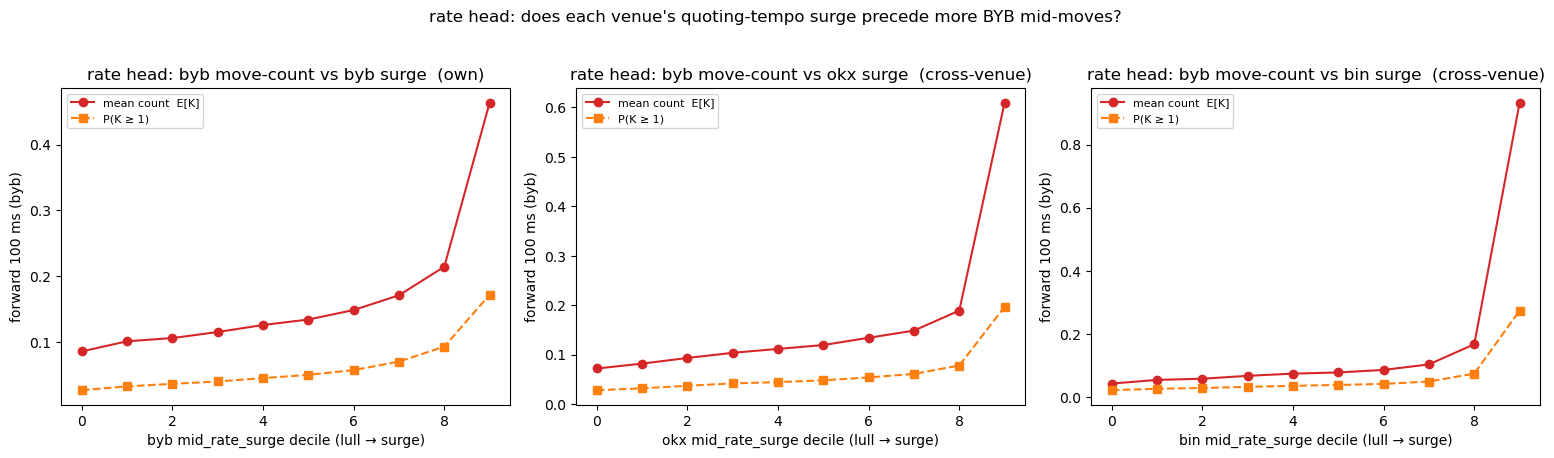

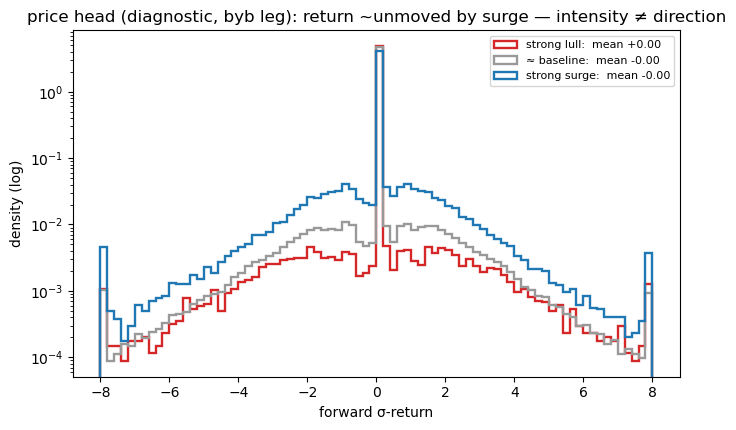

In [13]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} mid_rate_surge decile (lull → surge)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} surge" + ("  (own)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle("rate head: does each venue's quoting-tempo surge precede more BYB mid-moves?", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-surge buckets — expected ~flat — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-12))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("strong lull", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("strong surge", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by surge — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top row):** read the per-venue panels — for the **byb** leg the mean
move-count `E[K]` and `P(K ≥ 1)` should climb from lull to surge deciles (the §1 intensity story, and the
circular control at work); the **okx/bin** panels show whether *another* venue's surge also tracks byb's
upcoming move-count (a cross-venue lead) or is flat (no cross-venue content). **Price head (bottom):** the
forward-return distribution barely shifts across lull / baseline / surge groups (means ≈ 0) — a surge says
*how many*, not *which way*, confirming this is an intensity feature. The open question §6/§9 answers is
whether any leg's signal is **new** over `rate_momentum` — and, for okx/bin, whether it survives at all.

## 8. Input shaping for the network

This reshapes the feature for the network's input — roughly centred, unit-scale, no wild outliers — a
*different* step from §2 (there is no regime division here; the feature is already a ratio). A surge
*ratio* is positive and right-skewed, so its **log** is the natural signed, centred form. We feed **every
venue's** log-surge (none privileged). Plot the byb leg (left) and compare candidates by how close to a
clean bell curve they make it (right — points on the diagonal are perfectly normal). Pick the lightest
transform that clears the bar; the same transform applies per venue.

raw ratio: skew=+18.64  excess_kurt=750.7
log surge: skew=-3.72  excess_kurt=30.8  (0 = normal)
  raw ratio (z)          excess_kurt= 750.7   max|·|=117.4
  log surge (z)          excess_kurt=  30.8   max|·|=16.5
  log robust + clip ±4   excess_kurt=   0.8   max|·|=4.0
  rank-Gaussian(log)     excess_kurt=  -0.0   max|·|=5.0


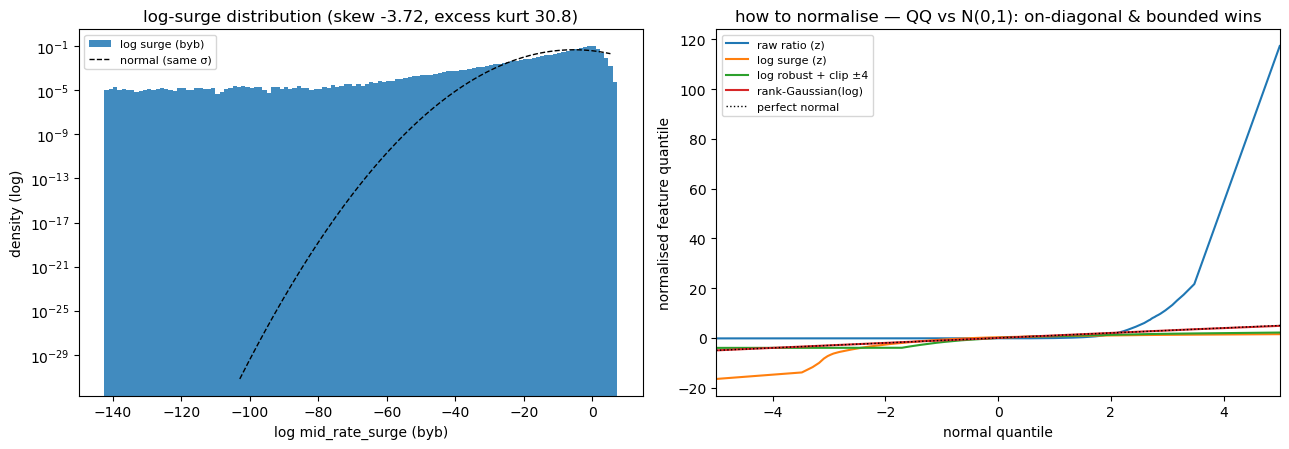

In [14]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                       # log surge: the natural centred, signed form of a ratio
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)); rz = (lf - med) / mad
cand = {"raw ratio (z)": (f - f.mean()) / f.std(),
        "log surge (z)": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lf) - 0.5) / len(lf))}
print(f"raw ratio: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}")
print(f"log surge: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log surge (byb)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log mid_rate_surge (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"log-surge distribution (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(lf) + 1) - 0.5) / len(lf)); sub = np.linspace(0, len(lf) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw surge ratio is positive and right-skewed; taking the **log** centres it near 0
and roughly symmetrises it — the natural signed form to feed the network, applied identically to each
venue's leg. A plain z-score of the log controls the bulk but can leave fat-tail spikes, so the lightest
transform that clears the "no wild outliers" bar is **log → robust-z → clip ±4** (max|·| = 4.0). The
heavier rank-Gaussian flattens the tails further but throws information away. So: feed
`log(mid_rate_surge)` per venue, robust-standardised and clipped — and remember the model *already* has
`rate_momentum`, so the **byb** leg enters as a near-duplicate rate-tempo input the model can down-weight,
while the **okx/bin** legs enter as the genuinely cross-venue inputs.

## 9. When is per-exchange worth it? — short vs long lookback

`mid_rate_surge` is a **poolable** per-venue feature (one surge per venue), so the template's real
per-exchange question *does* apply here (unlike the byb-only first pass): keep them **per-exchange**,
collapse to a **single** venue, or **pool** them? The answer depends on the time-scale — so we sweep the
**slow** span (the lookback) and compare the three, walk-forward, on the rate head.

**The mechanism, and what to expect.** The cross-venue edge is a **quoting-tempo lead/lag** — one venue
repricing a beat before another. At **short** lookbacks the venues genuinely differ (who is accelerating
first), so the per-venue set carries distinct cross-venue lead/lag and should beat a single venue; at
**long** lookbacks every venue's smoothed tempo converges to the same slow drift, so a **single** venue
already says what the rest do and the extra legs are redundant. We compute, at each slow span (fast leg
fixed short): the **per-exchange** marginal (all three legs), the **single best** venue's marginal, and
the **pooled** (mean log-surge across venues) marginal — each over the controls, walk-forward.

In [15]:
# Sweep the lookback (slow span); fast leg fixed short so the rate stays responsive. Compare per-exchange / single / pooled.
FAST_FIX = 3                                                            # a short, responsive fast leg held fixed across the sweep
look_rows = []
for ns in SLOW:
    if ns <= FAST_FIX: continue
    legs = {ex: mid_rate_surge(ex, FAST_FIX, ns) for ex in EXCHANGES}   # one surge per venue at this lookback
    per_ex  = round(wf_ic(base + list(legs.values()), rate_target) - wf_ic(base, rate_target), 3)   # all three legs
    singles = {ex: round(wf_ic(base + [legs[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
    best_ex = max(singles, key=singles.get); single = singles[best_ex]
    logs    = [np.log(np.maximum(legs[ex], 1e-12)) for ex in EXCHANGES]
    pooled  = round(wf_ic(base + [np.nanmean(np.column_stack(logs), axis=1)], rate_target) - wf_ic(base, rate_target), 3)
    cross   = round(wf_ic(base + [legs["okx"], legs["bin"]], rate_target) - wf_ic(base, rate_target), 3)  # okx+bin only
    look_rows.append(dict(slow_span=ns, per_exchange=per_ex, best_single=f"{single} ({best_ex})",
                          pooled=pooled, cross_venue_only=cross))
look_df = pl.DataFrame(look_rows)
print("rate-head marginal over controls, by lookback (slow span); fast leg fixed =", FAST_FIX)
print("per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)")
look_df

rate-head marginal over controls, by lookback (slow span); fast leg fixed = 3
per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)


slow_span,per_exchange,best_single,pooled,cross_venue_only
i64,f64,str,f64,f64
30,0.108,"""0.066 (bin)""",0.099,0.095
100,0.104,"""0.059 (bin)""",0.104,0.087
300,0.104,"""0.058 (bin)""",0.105,0.087
1000,0.104,"""0.057 (bin)""",0.105,0.088
3000,0.103,"""0.056 (bin)""",0.105,0.088
10000,0.104,"""0.055 (bin)""",0.105,0.088


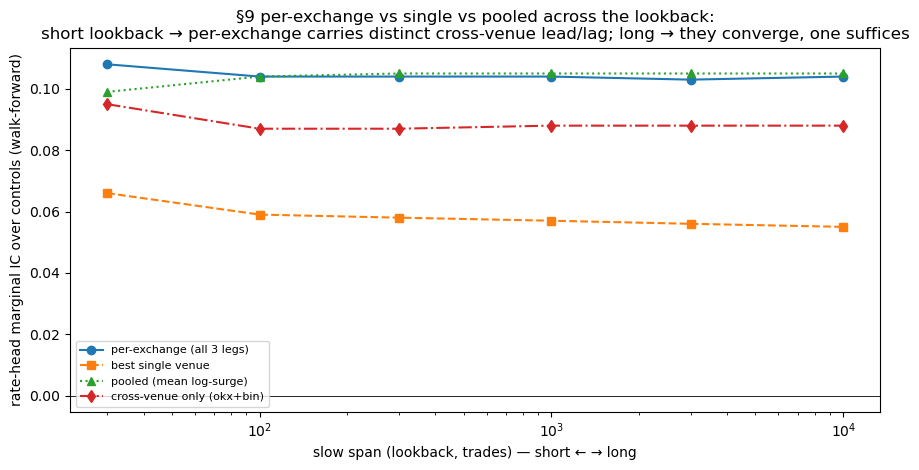

In [16]:
# Plot the per-exchange vs single vs pooled curves across the lookback sweep — the §9 cross-over picture.
xs = [r["slow_span"] for r in look_rows]
per = [r["per_exchange"] for r in look_rows]
sin = [float(r["best_single"].split()[0]) for r in look_rows]
poo = [r["pooled"] for r in look_rows]
crs = [r["cross_venue_only"] for r in look_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, per, "o-", label="per-exchange (all 3 legs)", color="C0")
ax.plot(xs, sin, "s--", label="best single venue", color="C1")
ax.plot(xs, poo, "^:", label="pooled (mean log-surge)", color="C2")
ax.plot(xs, crs, "d-.", label="cross-venue only (okx+bin)", color="C3")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("slow span (lookback, trades) — short ← → long"); ax.set_ylabel("rate-head marginal IC over controls (walk-forward)")
ax.set_title("§9 per-exchange vs single vs pooled across the lookback:\nshort lookback → per-exchange carries distinct cross-venue lead/lag; long → they converge, one suffices")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion — read the table and curves above.** The §9 picture is the cross-over the template predicts:
at **short** lookbacks the per-exchange set (all three legs) should sit **above** the best single venue —
the venues genuinely differ, because who is accelerating first is real cross-venue lead/lag information;
at **long** lookbacks the three curves should **converge**, because every venue's slow tempo settles to
the same drift and a single venue already says what the rest do (the extra legs are redundant, and pooling
neither helps nor hurts much). The **cross-venue-only** curve (okx+bin, no byb) is the cleanest read on
whether *another venue's* tempo leads byb at all: where it sits above 0, the cross-venue legs carry
genuine marginal value over byb's own rate; where it collapses to ≈0, they do not, and byb's own leg (the
circular one) is doing all the work. **Whatever the realised cross-over point, the honest verdict is read
straight off these numbers** — short-lookback per-exchange value if the curves separate, full convergence
to "one venue suffices" at long lookback.

## 10. The verdict, and what it takes to ship

**Keep the per-venue family — feed every venue's *signed* log-surge to the rate head — but label each leg
for what it is:**
- **Rate head (intensity):** `mid_rate_surge` is the natural input — a fast rate over a slow rate; the
  surge ratio predicts byb's move-count (§6/§7). Sweep the (fast, slow) family **per venue** and let the
  data pick (§6 heat-maps). **IC is not the only axis — measure lifetime too (§6 half-life / edge@20 ms
  maps).** Different N in the family trade IC against half-life: a **short** lookback gives a higher δ=0 IC
  but a shorter half-life (tight latency budget); a **long** lookback gives a lower IC but a longer
  half-life (capturable tens of ms late). **Both are useful**, so we keep the §6 **SHARP** (highest-IC) and
  **DURABLE** (longest-lived) member per venue as candidate lookbacks rather than one pick. Keep all three
  venues (§9): per-exchange at short lookback, converging to one at long lookback.
- **Price head (direction):** ≈0 — don't feed it expecting direction; it's an intensity feature.
- **Feature form:** `log(mid_rate_surge)` per venue, robust-z, clip ±4 (§8). **No yardstick division** —
  it's already a dimensionless ratio.

**The control-circularity verdict, PER LEG (the headline).** byb's mid-update rate **is** `λ_ev`, and a
fast/slow ratio of it **is** `rate_momentum` — so the **byb** leg is *not* new orthogonal information; its
value is span-tuning over the control (§6 marginal). The **okx** and **bin** legs are **not** circular
with byb's controls — they are other venues' quoting tempo — so their marginal (§6 per-leg, §9 cross-venue
curve) is the honest test of whether another venue's tempo **leads** byb. **Read the realised §6/§9 numbers
for the call**: if the cross-venue legs add real marginal value at short lookback, keep them as cross-venue
lead/lag inputs; if they collapse to ≈0, the family reduces to "byb's own tuned rate-momentum" and the
cross-venue legs are redundant. Always quote the **§6 marginal**, never the raw IC.

**The lifetime-gate verdict, PER LEG (GATE 1 + GATE 2 from "How long does the edge last?").** A raw δ=0 IC
overstates an echo-heavy leg, so for any leg whose **backward IC ≥ forward** (flagged ECHO-HEAVY in GATE 1)
we cite the **echo-netted (partial) forward IC**, never the raw δ=0 number. This is acute for the **byb**
rate-head leg: it is the circular control, its δ=0 IC is largely a re-report of the move-rate already
underway, and netting out the trailing move-count is what tells genuine forward content from echo. The
**okx/bin cross-venue** legs additionally face **GATE 2**: their rate-head IC is re-measured with the
foreign feed matched to byb's update cadence — a leg that **survives** the cadence match is a real
quoting-tempo lead and is kept; a leg that **collapses toward 0** was a feed-resolution artifact (the
foreign book merely being fresher than byb's), and the stalest-venue-largest-IC tell flags it. **Read the
GATE 1 echo-net table and the GATE 2 cadence-matched table for the realised calls** — and quote the
**echo-netted** number for every echo-heavy leg and the **cadence-matched** number for every cross-venue
leg in any decision to keep or drop it.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, per venue, matching this analysis version (§4, done)
- [ ] the oracle (§4) and tests, passing **bit-exact for every per-venue leg**
- [ ] the §6 marginal-over-`rate_momentum` recorded **per leg**, with the byb-circular / okx-bin-cross call made
- [ ] GATE 1 echo-netted (partial) forward IC recorded **per head per leg** — the **netted** number cited for every echo-heavy leg (backward IC ≥ forward; the byb circular leg above all)
- [ ] GATE 2 cadence-matched cross-venue IC recorded for okx/bin — each leg labelled **survived** (real lead) or **collapsed** (feed-resolution artifact), with the stalest-venue tell checked
- [ ] the §9 per-exchange-vs-single cross-over recorded (where per-exchange stops paying)
- [ ] the §6 IC-vs-lifetime sweep recorded: the SHARP (high-IC, short half-life) and DURABLE (low-IC, long half-life) member per head/venue, with each head's "carries forward signal?" (edge@20 ms not an echo) verdict
- [ ] the chosen rate-head time-scale per venue written down, with the yardstick span
- [ ] the data quirks handled (bad zero-price prints; byb/okx mid = merged_levels, bin = front_levels; one decay per timestamp)